In [4]:
# ============================================================
# NOTEBOOK 22: NEURAL NETWORK (MLP) CLASSIFIER
# BIRDS CubeSat Autonomous Power Management
# ------------------------------------------------------------
# Algorithm : Multi-Layer Perceptron — feedforward neural net
#             trained via backpropagation + gradient descent
# Forward   : ŷ = softmax(Wᴸ · σ(Wᴸ⁻¹ · ... σ(W¹x + b¹)))
# Loss      : L = -Σᵢ yᵢ log(ŷᵢ) + α·Σ_w w²  (cross-entropy + L2)
# Backward  : ∂L/∂Wˡ = δˡ⁺¹·(hˡ)ᵀ  via chain rule
# Update    : W ← W - η·∇_W L  (Adam adaptive)
# Minimum   : Tune hidden_layer_sizes, neurons, learning_rate,
#             activation, epochs (max_iter)
# IMPORTANT : MLPClassifier has NO class_weight param.
#             Use compute_sample_weight('balanced') instead.
# ============================================================

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
warnings.filterwarnings('ignore')
%matplotlib inline

import sklearn
print(f"scikit-learn {sklearn.__version__}")

# Core MLP classifier
from sklearn.neural_network import MLPClassifier

# Preprocessing — StandardScaler is MANDATORY for MLP
# (gradient descent: unscaled features cause vanishing/exploding gradients)
from sklearn.preprocessing import StandardScaler, label_binarize

# Model selection
from sklearn.model_selection import (
    TimeSeriesSplit,        # preserves temporal order — no future leakage
    RandomizedSearchCV,     # efficient for high-dimensional param space
    cross_val_score,
    learning_curve
)

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# Advanced analysis
from sklearn.inspection import permutation_importance   # MLP has no built-in feature importance
from sklearn.calibration  import calibration_curve      # reliability of predicted probabilities
from sklearn.decomposition import PCA                   # for hidden layer visualisation
from sklearn.utils.class_weight import compute_sample_weight  # replaces class_weight param
from scipy.stats import loguniform                      # log-uniform sampling for alpha, lr

SEED = 42
np.random.seed(SEED)

# Global plot style — consistent across all cells
plt.rcParams.update({
    'figure.dpi': 100, 'font.size': 10, 'axes.titlesize': 12,
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.grid': True, 'grid.alpha': 0.3,
})

# Shared colour scheme used across all plots
TASK_COLORS = ['#e74c3c', '#3498db', '#2ecc71']
TASK_TITLES = ['Task 1: Power State', 'Task 2: Eclipse State', 'Task 3: Power Level']
TNAMES      = ['Task1_PowerState', 'Task2_EclipseState', 'Task3_PowerLevel']
ROC_COLORS  = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

print("All imports successful.")

scikit-learn 1.7.2
All imports successful.


In [5]:
# ============================================================
# SECTION 2: LOAD DATASET — LOCAL FILE (LAPTOP)
# Looks for TSURU_cleaned.csv or .xlsx in current directory
# or common locations. Update FILE_PATH if needed.
# ============================================================

import glob

# Search current directory and subfolders first
matches = (glob.glob('**/TSURU_cleaned*.csv', recursive=True) +
           glob.glob('**/TSURU_cleaned*.xlsx', recursive=True))

if matches:
    FILE_PATH = matches[0]
else:
    # Manually set path if not found automatically
    FILE_PATH = 'TSURU_cleaned.csv'   # ← update this if needed

print(f"Loading: {FILE_PATH}")
df = pd.read_csv(FILE_PATH) if FILE_PATH.endswith('.csv') else pd.read_excel(FILE_PATH)

print(f"\nDataset shape  : {df.shape}")
print(f"Columns        : {list(df.columns)}")
df.head(3)

Loading: Downloads\ML_project\TSURU_cleaned.csv

Dataset shape  : (23259, 35)
Columns        : ['Time stamp', 'Tpy (°C)', 'Tpx (°C)', 'Tmz (°C)', 'Tmx (°C)', 'Tpz (°C)', 'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)', 'Ipy (mA)', 'Ipx (mA)', 'Imz (mA)', 'Imx (mA)', 'Ipz (mA)', 'Vbat (V)', 'Ibatt(mA)', 'Tbatt (℃)', 'Date', 'Ppy (µW)', 'Ppx (µW)', 'Pmz (µW)', 'Pmx (µW)', 'Ppz (µW)', 'P_solar_total (µW)', 'P_batt (µW)', 'T_panel_avg (°C)', 'ΔT_batt_panel (°C)', 'V_panel_avg (mV)', 'sin_orbit', 'cos_orbit', 'Eclipse', 'Charging', 'Power_Level']


,Time stamp,Tpy (°C),Tpx (°C),Tmz (°C),Tmx (°C),Tpz (°C),Vpy (mV),Vpx (mV),Vmz (mV),Vmx (mV),...,P_solar_total (µW),P_batt (µW),T_panel_avg (°C),ΔT_batt_panel (°C),V_panel_avg (mV),sin_orbit,cos_orbit,Eclipse,Charging,Power_Level
0,0.0,4.63,6.19,-3.91,-0.81,8.29,1326.31,1272.89,1288.16,1318.68,...,36493.3454,1151731.0,2.878,7.382,1297.618,0.000000,1.000000,1,0,Low
1,11.3,4.30,5.96,-4.02,-1.25,7.85,1326.31,1272.89,1288.16,1318.68,...,30518.9924,1199742.0,2.568,7.692,1297.618,0.012779,0.999918,1,0,Low
2,22.6,3.63,5.41,-4.36,-1.58,7.30,1326.31,1272.89,1288.16,1320.21,...,30518.9924,1439879.0,2.080,8.180,1297.924,0.025555,0.999673,1,0,Low


In [6]:
# ============================================================
# SECTION 3: FEATURE ENGINEERING & CLASSIFICATION TASK SETUP
# ------------------------------------------------------------
# Dataset columns confirmed:
#   Panel voltages : Vpx (mV), Vpy (mV), Vmx (mV), Vmz (mV), Vpz (mV)
#   Panel temps    : Tpx (°C), Tpy (°C), Tmx (°C), Tmz (°C), Tpz (°C)
#   Battery temp   : Tbatt (℃)
#   Battery voltage: Vbat (V)
#   Orbital        : sin_orbit, cos_orbit  ← already in dataset, no engineering needed
#   Target cols    : Eclipse, Charging, Power_Level (Low/Medium/High strings)
# ============================================================

# ── sin_orbit & cos_orbit already exist in dataset ──────────
# No need to compute from orbit_fraction — dataset already has them

# ── TASK 1: Power State — 3 classes ─────────────────────────
# CRITICAL: Vbat < 3.90V (Vbat range in dataset: 3.79 – 4.20V)
def assign_power_state(row):
    if   row['Vbat (V)'] < 3.90:   return 2   # CRITICAL
    elif row['Charging']  == 1:     return 0   # CHARGING
    else:                           return 1   # DISCHARGING

df['power_state'] = df.apply(assign_power_state, axis=1)

# ── TASK 2: Eclipse State — 2 classes ───────────────────────
df['eclipse_state'] = df['Eclipse'].astype(int)   # 0=sunlight, 1=eclipse

# ── TASK 3: Power Level — 3 classes ─────────────────────────
# Power_Level already exists as strings (Low/Medium/High)
# Map to integers: High=0, Medium=1, Low=2
df['power_level'] = df['Power_Level'].map({'High':0, 'Medium':1, 'Low':2})

# ── Feature groups (using exact column names from dataset) ───
PANEL_V  = ['Vpx (mV)', 'Vpy (mV)', 'Vmx (mV)', 'Vmz (mV)', 'Vpz (mV)']
PANEL_T  = ['Tpx (°C)', 'Tpy (°C)', 'Tmx (°C)', 'Tmz (°C)', 'Tpz (°C)']
ORBIT_FT = ['sin_orbit', 'cos_orbit']
SHARED   = PANEL_V + PANEL_T + ['Tbatt (℃)'] + ORBIT_FT

# Leakage-free features per task
# Task 1: exclude Charging, Ibatt(mA), P_batt (µW), Vbat (V)
TASK1_FEATS = [f for f in SHARED if f not in ['Charging','Ibatt(mA)','P_batt (µW)','Vbat (V)']]

# Task 2: exclude Eclipse, P_solar_total (µW), current columns
TASK2_FEATS = [f for f in SHARED if f not in ['Eclipse','P_solar_total (µW)',
               'Ipy (mA)','Ipx (mA)','Imz (mA)','Imx (mA)','Ipz (mA)']]

# Task 3: exclude Vbat (V), P_solar_total (µW), Charging, battery current/power
TASK3_FEATS = [f for f in SHARED if f not in ['Vbat (V)','P_solar_total (µW)',
               'Charging','Ibatt(mA)','P_batt (µW)']]

# ── Temporal 80/20 train/test split ─────────────────────────
split = int(len(df) * 0.80)

tasks_cfg = {
    'Task1_PowerState'  : ('power_state',   TASK1_FEATS, ['CHARGING','DISCHARGING','CRITICAL']),
    'Task2_EclipseState': ('eclipse_state', TASK2_FEATS, ['SUNLIGHT','ECLIPSE']),
    'Task3_PowerLevel'  : ('power_level',   TASK3_FEATS, ['HIGH','MEDIUM','LOW']),
}

DATA = {}
for tname, (target, feats, cls_names) in tasks_cfg.items():
    X = df[feats].values
    y = df[target].values
    Xtr, Xte = X[:split], X[split:]
    ytr, yte  = y[:split], y[split:]

    sc    = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    sw = compute_sample_weight('balanced', ytr) if tname == 'Task1_PowerState' else None

    DATA[tname] = dict(
        X_train=Xtr_s, X_test=Xte_s, y_train=ytr, y_test=yte,
        scaler=sc, features=feats, class_names=cls_names,
        target_col=target, sample_weight=sw
    )

    print(f"\n{tname}")
    print(f"  Features  : {len(feats)} → {feats}")
    print(f"  Train/Test: {len(Xtr):,} / {len(Xte):,}")
    for i, cn in enumerate(cls_names):
        cnt = int(np.sum(y == i))
        print(f"  Class {i} ({cn:12s}): {cnt:6,}  ({100*cnt/len(y):.1f}%)")

TSCV = TimeSeriesSplit(n_splits=5)
print(f"\nTimeSeriesSplit(n_splits=5) ready.")
print("StandardScaler applied — mandatory for MLP (gradient descent).")
print("sample_weight pre-computed for Task 1 (replaces class_weight).")


Task1_PowerState
  Features  : 13 → ['Vpx (mV)', 'Vpy (mV)', 'Vmx (mV)', 'Vmz (mV)', 'Vpz (mV)', 'Tpx (°C)', 'Tpy (°C)', 'Tmx (°C)', 'Tmz (°C)', 'Tpz (°C)', 'Tbatt (℃)', 'sin_orbit', 'cos_orbit']
  Train/Test: 18,607 / 4,652
  Class 0 (CHARGING    ): 13,523  (58.1%)
  Class 1 (DISCHARGING ):  9,571  (41.1%)
  Class 2 (CRITICAL    ):    165  (0.7%)

Task2_EclipseState
  Features  : 13 → ['Vpx (mV)', 'Vpy (mV)', 'Vmx (mV)', 'Vmz (mV)', 'Vpz (mV)', 'Tpx (°C)', 'Tpy (°C)', 'Tmx (°C)', 'Tmz (°C)', 'Tpz (°C)', 'Tbatt (℃)', 'sin_orbit', 'cos_orbit']
  Train/Test: 18,607 / 4,652
  Class 0 (SUNLIGHT    ): 15,537  (66.8%)
  Class 1 (ECLIPSE     ):  7,722  (33.2%)

Task3_PowerLevel
  Features  : 13 → ['Vpx (mV)', 'Vpy (mV)', 'Vmx (mV)', 'Vmz (mV)', 'Vpz (mV)', 'Tpx (°C)', 'Tpy (°C)', 'Tmx (°C)', 'Tmz (°C)', 'Tpz (°C)', 'Tbatt (℃)', 'sin_orbit', 'cos_orbit']
  Train/Test: 18,607 / 4,652
  Class 0 (HIGH        ):  7,753  (33.3%)
  Class 1 (MEDIUM      ):  7,753  (33.3%)
  Class 2 (LOW         ):  

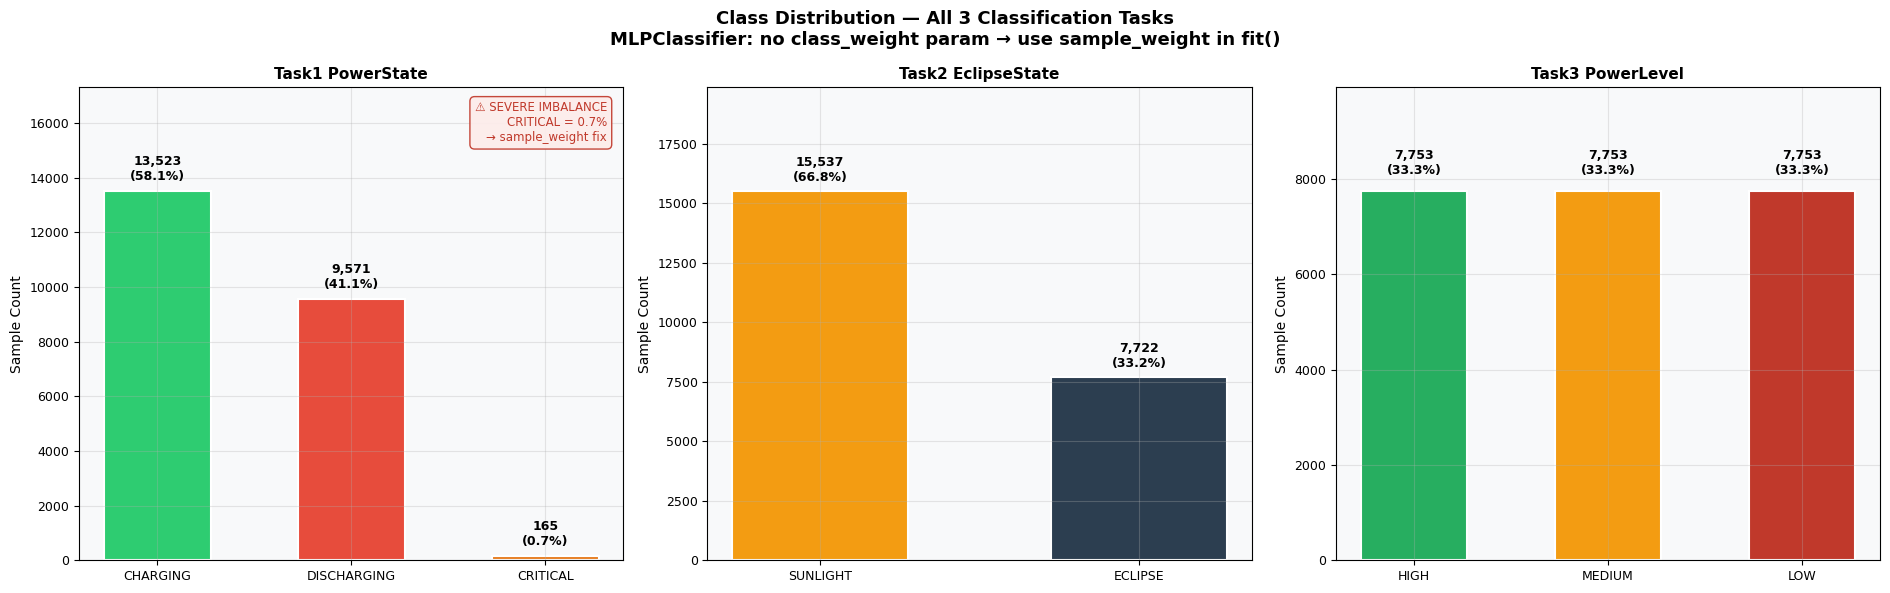

Plot saved: 00_class_distribution.png


In [ ]:
# ============================================================
# SECTION 4: CLASS DISTRIBUTION — EDA
# ------------------------------------------------------------
# Visualise class balance before training.
# CRITICAL class = 0.7% of Task 1. Without sample weighting,
# MLP achieves ~99.3% accuracy by never predicting CRITICAL.
# compute_sample_weight('balanced') raises CRITICAL weight ~70×.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Class Distribution — All 3 Classification Tasks\n'
             'MLPClassifier: no class_weight param → use sample_weight in fit()',
             fontsize=13, fontweight='bold')

palettes = [
    ['#2ecc71','#e74c3c','#e67e22'],
    ['#f39c12','#2c3e50'],
    ['#27ae60','#f39c12','#c0392b'],
]

for ax, tname, palette in zip(axes, TNAMES, palettes):
    d      = DATA[tname]
    y_all  = df[d['target_col']].values
    clsn   = d['class_names']
    counts = [int(np.sum(y_all == i)) for i in range(len(clsn))]
    total  = sum(counts)

    bars = ax.bar(clsn, counts, color=palette[:len(clsn)],
                  edgecolor='white', linewidth=1.5, width=0.55)

    for bar, cnt in zip(bars, counts):
        pct = 100 * cnt / total
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + total * 0.012,
                f'{cnt:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    if tname == 'Task1_PowerState':
        ax.text(0.97, 0.97,
                '⚠ SEVERE IMBALANCE\nCRITICAL = 0.7%\n→ sample_weight fix',
                transform=ax.transAxes, fontsize=8.5, va='top', ha='right',
                color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea',
                          edgecolor='#c0392b', alpha=0.92))

    ax.set_title(tname.replace('_',' '), fontweight='bold', fontsize=11)
    ax.set_ylabel('Sample Count')
    ax.set_ylim(0, max(counts) * 1.28)

plt.tight_layout()
plt.savefig('00_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 00_class_distribution.png")

##  Class Distribution
Task 1 (Power State): CHARGING 58.1% (13,523) | DISCHARGING 41.1% (9,571) | CRITICAL 0.7% (165)
Task 2 (Eclipse State): SUNLIGHT 66.8% (15,537) | ECLIPSE 33.2% (7,722)
Task 3 (Power Level): HIGH 33.3% | MEDIUM 33.3% | LOW 33.3% — perfectly balanced

**Critical note:** MLPClassifier has no `class_weight` parameter.
`compute_sample_weight('balanced')` passed to `fit()` raises CRITICAL weight ~70× to prevent the model ignoring it entirely.

In [ ]:
# ============================================================
# SECTION 5: BASE MLP — DEFAULT HYPERPARAMETERS
# ------------------------------------------------------------
# hidden_layer_sizes=(100,) — one hidden layer, 100 neurons
# activation='relu'         — ReLU: max(0,z), fastest convergence
# solver='adam'             — adaptive moments, robust default
# alpha=1e-4                — L2 regularisation weight
# learning_rate_init=0.001  — initial step size
# max_iter=500              — max training epochs
# loss_curve_ attribute     — track cross-entropy per iteration
# n_iter_      attribute    — actual epochs until convergence
# ------------------------------------------------------------
# Task 1: pass sample_weight to fit() — no class_weight param
# ============================================================

print("="*65)
print("BASE MLP  hidden=(100,) | relu | adam | alpha=1e-4 | lr=0.001")
print("="*65)

BASE_RESULTS = {}

for tname in TNAMES:
    d  = DATA[tname]
    t0 = time.time()

    mlp = MLPClassifier(
        hidden_layer_sizes=(100,),    # single hidden layer, 100 neurons
        activation='relu',            # ReLU activation for all hidden layers
        solver='adam',                # Adam: adaptive learning rate per weight
        alpha=1e-4,                   # L2 penalty: loss += alpha * sum(w²)
        learning_rate_init=0.001,     # initial lr (Adam adapts this per weight)
        max_iter=500,                 # maximum training epochs
        random_state=SEED
    )

    # Task 1: sample_weight compensates for CRITICAL class imbalance
    # Other tasks: no weighting needed (balanced or moderate imbalance)
    if d['sample_weight'] is not None:
        mlp.fit(d['X_train'], d['y_train'], sample_weight=d['sample_weight'])
    else:
        mlp.fit(d['X_train'], d['y_train'])
    elapsed = time.time() - t0

    yp   = mlp.predict(d['X_test'])
    acc  = accuracy_score(d['y_test'], yp)
    f1w  = f1_score(d['y_test'], yp, average='weighted')
    f1m  = f1_score(d['y_test'], yp, average='macro')
    prec = precision_score(d['y_test'], yp, average='weighted', zero_division=0)
    rec  = recall_score(d['y_test'], yp, average='weighted')

    cv   = cross_val_score(
        MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                      alpha=1e-4, learning_rate_init=0.001, max_iter=500, random_state=SEED),
        d['X_train'], d['y_train'], cv=TSCV, scoring='f1_weighted', n_jobs=-1
    )

    BASE_RESULTS[tname] = dict(
        model=mlp, acc=acc, f1w=f1w, f1m=f1m,
        prec=prec, rec=rec, cv_mean=cv.mean(), cv_std=cv.std(), y_pred=yp
    )

    print(f"\n{'─'*52}")
    print(f"  {tname}")
    print(f"  Classes         : {d['class_names']}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  F1 (weighted)   : {f1w:.4f}")
    print(f"  F1 (macro)      : {f1m:.4f}  ← equal weight per class")
    print(f"  Precision (wtd) : {prec:.4f}")
    print(f"  Recall (wtd)    : {rec:.4f}")
    print(f"  CV F1 mean±std  : {cv.mean():.4f} ± {cv.std():.4f}")
    print(f"  Epochs run      : {mlp.n_iter_}  (max={mlp.max_iter})")
    print(f"  Final loss      : {mlp.loss_:.6f}")
    print(f"  n_layers_       : {mlp.n_layers_}  (input + hidden + output)")
    print(f"  Training time   : {elapsed:.2f}s")
    print()
    print(classification_report(d['y_test'], yp, target_names=d['class_names'], zero_division=0))

BASE MLP  hidden=(100,) | relu | adam | alpha=1e-4 | lr=0.001

────────────────────────────────────────────────────
  Task1_PowerState
  Classes         : ['CHARGING', 'DISCHARGING', 'CRITICAL']
  Accuracy        : 0.8925
  F1 (weighted)   : 0.9110
  F1 (macro)      : 0.6679  ← equal weight per class
  Precision (wtd) : 0.9394
  Recall (wtd)    : 0.8925
  CV F1 mean±std  : 0.9339 ± 0.0193
  Epochs run      : 135  (max=500)
  Final loss      : 0.095924
  n_layers_       : 3  (input + hidden + output)
  Training time   : 18.57s

              precision    recall  f1-score   support

    CHARGING       0.94      0.97      0.96      2411
 DISCHARGING       0.96      0.81      0.88      2190
    CRITICAL       0.10      0.59      0.17        51

    accuracy                           0.89      4652
   macro avg       0.67      0.79      0.67      4652
weighted avg       0.94      0.89      0.91      4652


────────────────────────────────────────────────────
  Task2_EclipseState
  Classes  

##  Base MLP Results
Default config: hidden=(100,) | relu | adam | alpha=1e-4 | lr=0.001 | max_iter=500

| Task | Accuracy | F1-Weighted | F1-Macro | CV F1 | Epochs |
|------|----------|-------------|----------|-------|--------|
| Power State | 0.8925 | 0.9110 | 0.6679 | 0.9339 ± 0.0193 | 135 |
| Eclipse State | 0.9976 | 0.9976 | 0.9974 | 0.9952 ± 0.0036 | 37 |
| Power Level | 0.8149 | 0.8078 | 0.8005 | 0.7837 ± 0.0758 | 347 |

This is the reference baseline — all tuning improvements measured against these values.

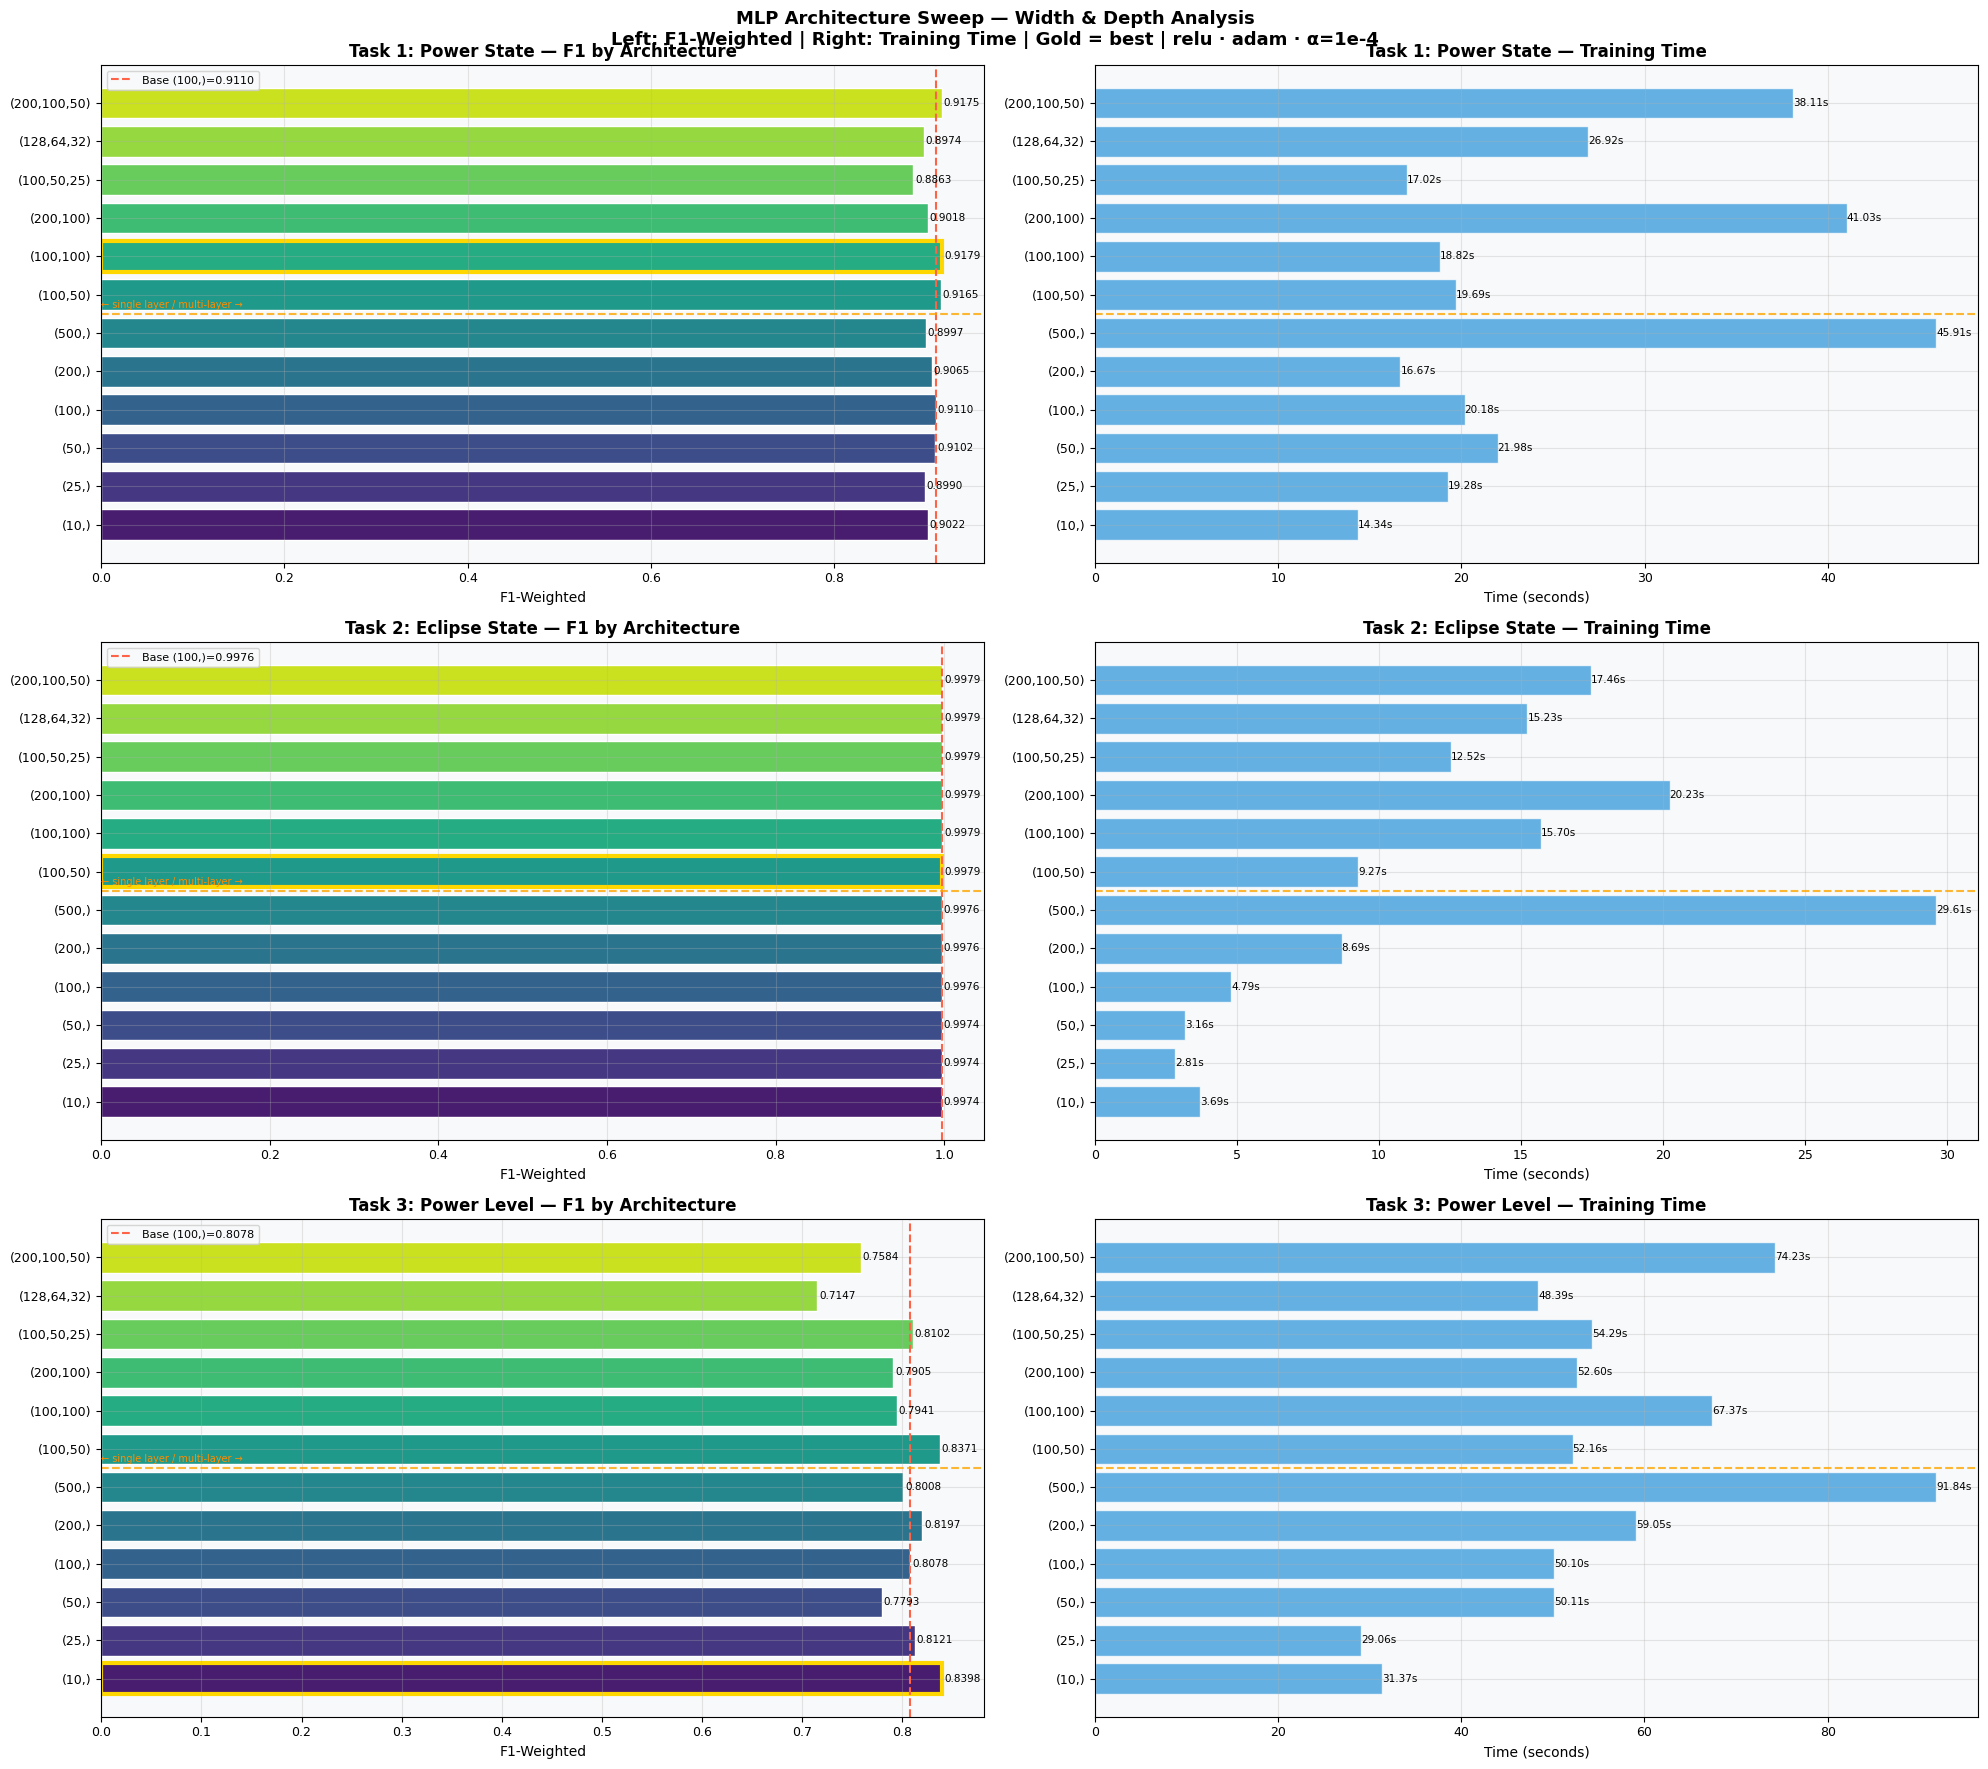

Plot saved: 01_architecture_sweep.png

Best architecture per task:
  Task1_PowerState: (100,100)  F1=0.9179  time=18.82s
  Task2_EclipseState: (100,50)  F1=0.9979  time=9.27s
  Task3_PowerLevel: (10,)  F1=0.8398  time=31.37s


In [ ]:
# ============================================================
# SECTION 6: ARCHITECTURE SWEEP — HIDDEN LAYER SIZES
# ------------------------------------------------------------
# hidden_layer_sizes controls the network topology:
#   (50,)        → 1 hidden layer, 50 neurons  (shallow-narrow)
#   (500,)       → 1 hidden layer, 500 neurons (shallow-wide)
#   (100,50)     → 2 hidden layers             (medium depth)
#   (100,50,25)  → 3 hidden layers             (deep)
# Deeper = learns more abstract orbital representations
# Wider  = more capacity per layer
# Gold-bordered bar = best architecture per task
# Orange divider separates single-layer vs multi-layer configs
# ============================================================

ARCHITECTURES = {
    '(10,)'        : (10,),
    '(25,)'        : (25,),
    '(50,)'        : (50,),
    '(100,)'       : (100,),
    '(200,)'       : (200,),
    '(500,)'       : (500,),
    '(100,50)'     : (100, 50),
    '(100,100)'    : (100, 100),
    '(200,100)'    : (200, 100),
    '(100,50,25)'  : (100, 50, 25),
    '(128,64,32)'  : (128, 64, 32),
    '(200,100,50)' : (200, 100, 50),
}

arch_res = {tn: {'labels':[], 'f1':[], 'sec':[]} for tn in TNAMES}

for aname, asize in ARCHITECTURES.items():
    for tn in TNAMES:
        d   = DATA[tn]
        mlp = MLPClassifier(hidden_layer_sizes=asize, activation='relu',
                            solver='adam', alpha=1e-4, max_iter=500, random_state=SEED)
        t0  = time.time()
        if d['sample_weight'] is not None:
            mlp.fit(d['X_train'], d['y_train'], sample_weight=d['sample_weight'])
        else:
            mlp.fit(d['X_train'], d['y_train'])
        elapsed = time.time() - t0
        yp = mlp.predict(d['X_test'])
        arch_res[tn]['labels'].append(aname)
        arch_res[tn]['f1'].append(f1_score(d['y_test'], yp, average='weighted'))
        arch_res[tn]['sec'].append(elapsed)

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('MLP Architecture Sweep — Width & Depth Analysis\n'
             'Left: F1-Weighted | Right: Training Time | Gold = best | relu · adam · α=1e-4',
             fontsize=13, fontweight='bold')

arch_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(ARCHITECTURES)))
DIVIDER = 5.5   # separates single-layer from multi-layer

for row, (tn, ttitle) in enumerate(zip(TNAMES, TASK_TITLES)):
    ar     = arch_res[tn]
    labels = ar['labels']
    f1s    = ar['f1']
    secs   = ar['sec']

    # Left panel: F1 horizontal bar chart
    ax_f = axes[row, 0]
    bars = ax_f.barh(labels, f1s, color=arch_colors, edgecolor='white')

    # Gold border on best architecture
    best_i = int(np.argmax(f1s))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(3)

    for bar, v in zip(bars, f1s):
        ax_f.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                  f'{v:.4f}', va='center', fontsize=7.5)

    # Base model reference line
    ax_f.axvline(f1s[3], color='tomato', ls='--', lw=1.5,
                 label=f'Base (100,)={f1s[3]:.4f}')
    # Divider between single vs multi-layer
    ax_f.axhline(DIVIDER, color='orange', ls='--', lw=1.5, alpha=0.8)
    ax_f.text(ax_f.get_xlim()[0], DIVIDER + 0.15,
              '← single layer / multi-layer →', fontsize=7, color='darkorange')

    ax_f.set_title(f'{ttitle} — F1 by Architecture', fontweight='bold')
    ax_f.set_xlabel('F1-Weighted')
    ax_f.legend(fontsize=8)

    # Right panel: training time
    ax_t = axes[row, 1]
    ax_t.barh(labels, secs, color='#3498db', alpha=0.75, edgecolor='white')
    for bar, v in zip(ax_t.patches, secs):
        ax_t.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                  f'{v:.2f}s', va='center', fontsize=7.5)
    ax_t.axhline(DIVIDER, color='orange', ls='--', lw=1.5, alpha=0.8)
    ax_t.set_title(f'{ttitle} — Training Time', fontweight='bold')
    ax_t.set_xlabel('Time (seconds)')

plt.tight_layout()
plt.savefig('01_architecture_sweep.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 01_architecture_sweep.png")

print("\nBest architecture per task:")
for tn in TNAMES:
    bi = int(np.argmax(arch_res[tn]['f1']))
    print(f"  {tn}: {arch_res[tn]['labels'][bi]}  F1={arch_res[tn]['f1'][bi]:.4f}  "
          f"time={arch_res[tn]['sec'][bi]:.2f}s")

##  Architecture Sweep

| Architecture | Task 1 F1 | Task 2 F1 | Task 3 F1 | Time |
|-------------|-----------|-----------|-----------|------|
| (10,) | 0.9022 | 0.9974 | **0.8398** | 31s |
| (100,) Base | 0.9110 | 0.9976 | 0.8078 | 20s |
| (100,50) | 0.9165 | **0.9979** | 0.8371 | 20s |
| **(100,100)** | **0.9179** | 0.9979 | 0.7941 | 19s |
| (200,100,50) | 0.9175 | 0.9979 | 0.7584 | 38s |

- Task 1 best: **(100,100)** — equal layers capture CHARGING/DISCHARGING symmetry
- Task 2 best: **(100,50)** — any architecture works, eclipse is trivially separable
- Task 3 best: **(10,)** — power level tertile bins are simple voltage thresholds, shallow net avoids overfitting HIGH/MEDIUM overlap

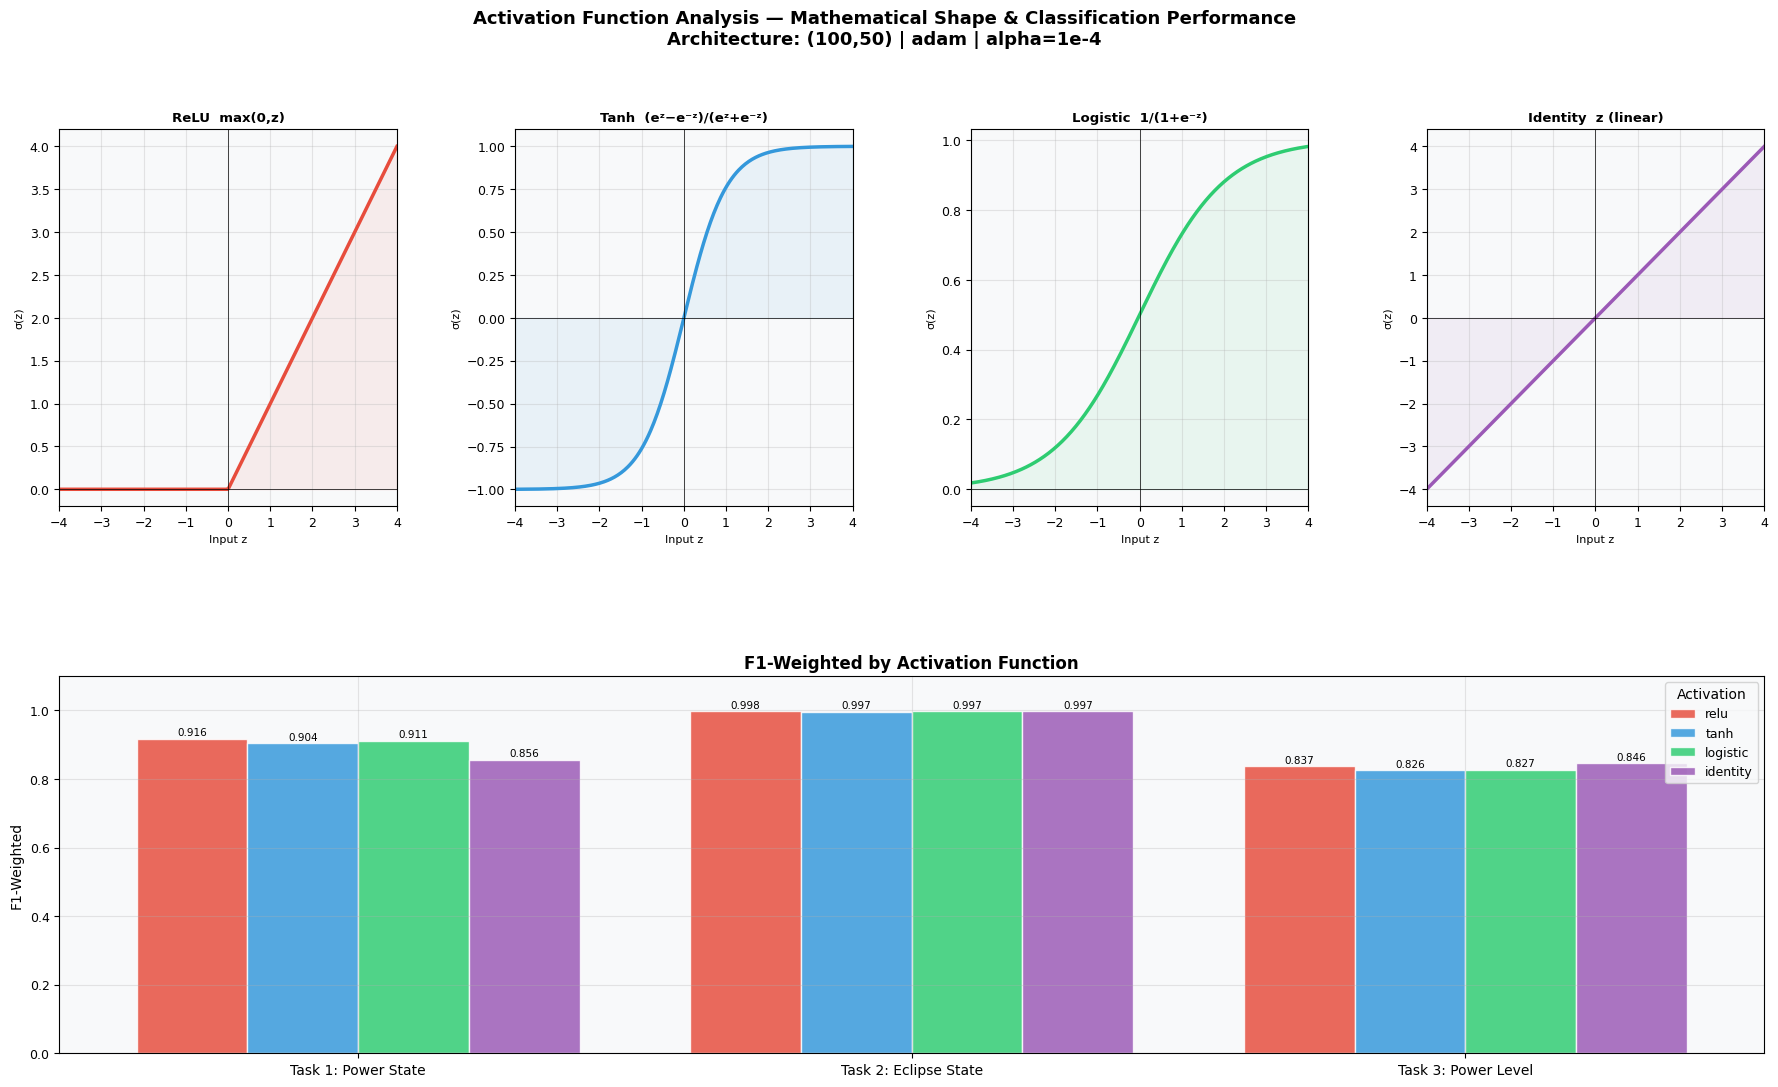

Plot saved: 02_activation_comparison.png

Convergence Epochs by Activation:
Activation        Task1 PowerState    Task2 EclipseState      Task3 PowerLevel
relu                            75                    38                   216
tanh                           121                    44                   328
logistic                       125                    36                   500
identity                        45                    31                    29


In [ ]:
# ============================================================
# SECTION 7: ACTIVATION FUNCTION COMPARISON
# ------------------------------------------------------------
# relu     : σ(z) = max(0,z)          — fastest, no vanishing grad
# tanh     : σ(z) = (eᶻ-e⁻ᶻ)/(eᶻ+e⁻ᶻ) — zero-centred, smooth
# logistic : σ(z) = 1/(1+e⁻ᶻ)        — sigmoid, saturation risk
# identity : σ(z) = z                  — linear, collapses depth
# Top row: mathematical shapes of each function
# Bottom row: grouped bar chart of F1 per task
# Architecture fixed: (100,50) | solver=adam | alpha=1e-4
# ============================================================

ACTIVATIONS = {
    'relu'    : ('#e74c3c', 'ReLU  max(0,z)'),
    'tanh'    : ('#3498db', 'Tanh  (eᶻ−e⁻ᶻ)/(eᶻ+e⁻ᶻ)'),
    'logistic': ('#2ecc71', 'Logistic  1/(1+e⁻ᶻ)'),
    'identity': ('#9b59b6', 'Identity  z (linear)'),
}

act_res = {tn: {} for tn in TNAMES}

for act_name in ACTIVATIONS:
    for tn in TNAMES:
        d   = DATA[tn]
        mlp = MLPClassifier(hidden_layer_sizes=(100, 50), activation=act_name,
                            solver='adam', alpha=1e-4, max_iter=500, random_state=SEED)
        if d['sample_weight'] is not None:
            mlp.fit(d['X_train'], d['y_train'], sample_weight=d['sample_weight'])
        else:
            mlp.fit(d['X_train'], d['y_train'])
        yp = mlp.predict(d['X_test'])
        act_res[tn][act_name] = dict(
            f1=f1_score(d['y_test'], yp, average='weighted'),
            acc=accuracy_score(d['y_test'], yp),
            iters=mlp.n_iter_, loss=mlp.loss_
        )

# ── Plot: function shapes (top row) + grouped F1 bars (bottom) ────────
fig = plt.figure(figsize=(22, 12))
gs  = GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Activation Function Analysis — Mathematical Shape & Classification Performance\n'
             'Architecture: (100,50) | adam | alpha=1e-4',
             fontsize=13, fontweight='bold')

x = np.linspace(-4, 4, 300)
fn_map = {
    'relu'    : np.maximum(0, x),
    'tanh'    : np.tanh(x),
    'logistic': 1 / (1 + np.exp(-x)),
    'identity': x,
}

# Top row: plot each activation function's mathematical shape
for col, (act_name, (col_c, label)) in enumerate(ACTIVATIONS.items()):
    ax = fig.add_subplot(gs[0, col])
    ax.plot(x, fn_map[act_name], color=col_c, linewidth=2.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.fill_between(x, 0, fn_map[act_name], alpha=0.08, color=col_c)
    ax.set_title(label, fontweight='bold', fontsize=9.5)
    ax.set_xlabel('Input z', fontsize=8)
    ax.set_ylabel('σ(z)', fontsize=8)
    ax.set_xlim(-4, 4)

# Bottom row: grouped bar comparing F1 per task per activation
ax_b = fig.add_subplot(gs[1, :])
act_names = list(ACTIVATIONS.keys())
n_acts    = len(act_names)
x_pos     = np.arange(len(TNAMES))
width     = 0.20

for i, (act_name, (col_c, _)) in enumerate(ACTIVATIONS.items()):
    f1s    = [act_res[tn][act_name]['f1'] for tn in TNAMES]
    offset = (i - n_acts/2 + 0.5) * width
    bars   = ax_b.bar(x_pos + offset, f1s, width=width,
                      label=act_name, color=col_c, alpha=0.83, edgecolor='white')
    for bar, v in zip(bars, f1s):
        ax_b.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.004,
                  f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax_b.set_xticks(x_pos)
ax_b.set_xticklabels(TASK_TITLES, fontsize=10)
ax_b.set_ylabel('F1-Weighted')
ax_b.set_title('F1-Weighted by Activation Function', fontweight='bold')
ax_b.legend(title='Activation', fontsize=9)
ax_b.set_ylim(0, 1.10)

plt.savefig('02_activation_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 02_activation_comparison.png")

# Print convergence table
print("\nConvergence Epochs by Activation:")
print(f"{'Activation':12}", end='')
for tn in TNAMES:
    print(f"  {tn.replace('_',' ')[:20]:>20}", end='')
print()
for aname in act_names:
    print(f"{aname:12}", end='')
    for tn in TNAMES:
        print(f"  {act_res[tn][aname]['iters']:>20}", end='')
    print()

##  Activation Function Comparison
Architecture fixed: (100,50) | adam | alpha=1e-4

| Activation | Task 1 F1 | Task 2 F1 | Task 3 F1 | T1 Epochs | T3 Epochs |
|-----------|-----------|-----------|-----------|-----------|-----------|
| **ReLU** | **0.916** | 0.998 | **0.837** | **75** | 216 |
| Tanh | 0.904 | 0.997 | 0.826 | 121 | 328 |
| Logistic | 0.911 | 0.997 | 0.827 | 125 | 500 ← no converge |
| Identity | 0.856 | 0.997 | 0.846 | 45 | **29** |

- **ReLU** — best F1 + fastest meaningful convergence (75 epochs Task 1)
- **Logistic** — Task 3 never converged in 500 epochs (vanishing gradients)
- **Identity** — fastest epochs but worst F1 — collapses multi-layer into single linear layer

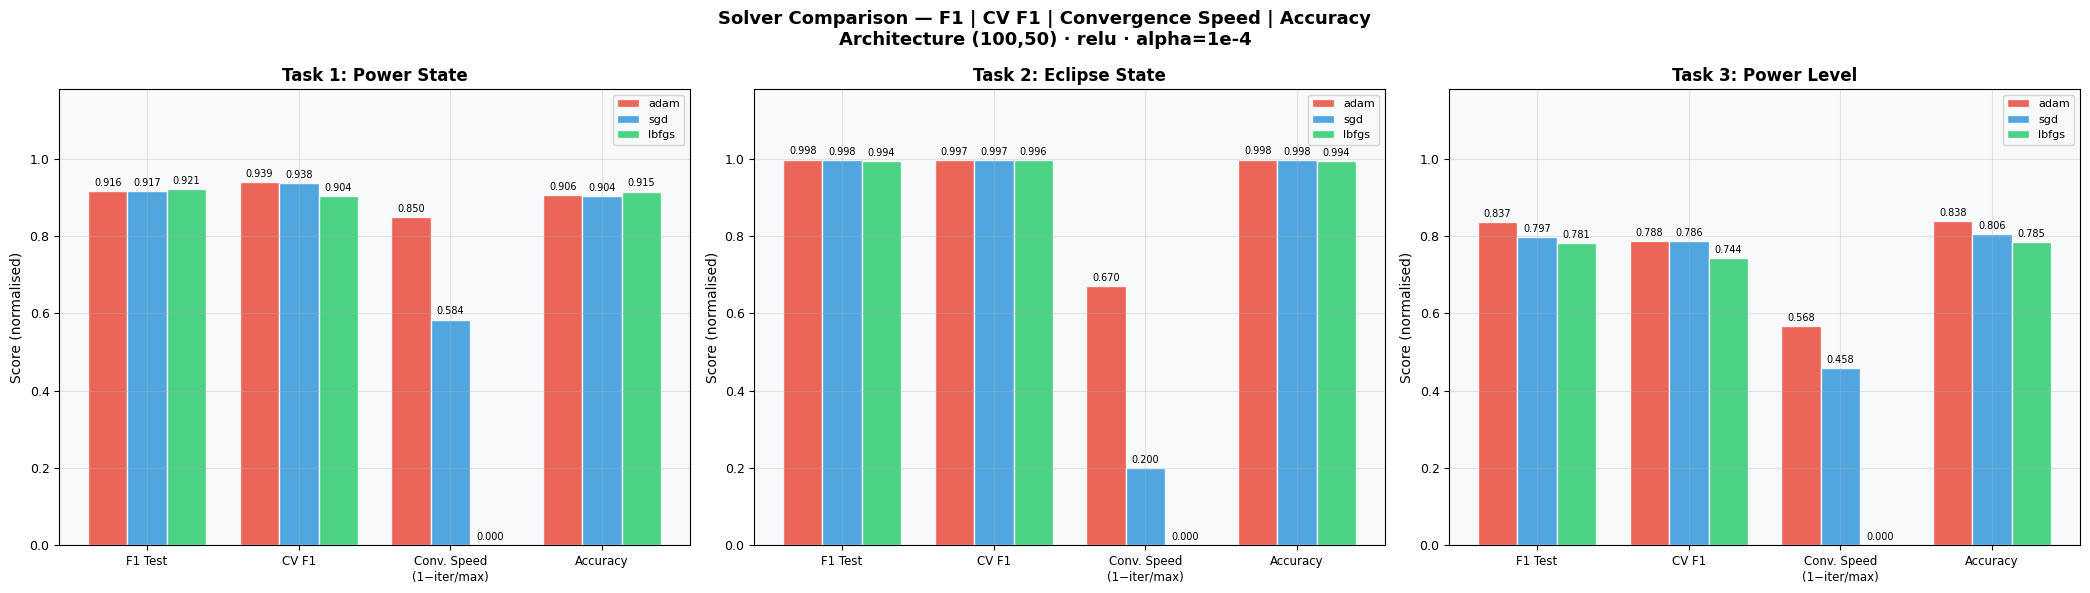

Plot saved: 03_solver_comparison.png

Solver   Task                      F1      CV F1   Iters   Time    
------------------------------------------------------------
adam     Task1_PowerState          0.9165  0.9387     75  18.31s
adam     Task2_EclipseState        0.9979  0.9974     38  9.02s
adam     Task3_PowerLevel          0.8371  0.7875    216  53.58s
sgd      Task1_PowerState          0.9169  0.9377    208  51.29s
sgd      Task2_EclipseState        0.9976  0.9974     92  20.48s
sgd      Task3_PowerLevel          0.7972  0.7864    271  63.52s
lbfgs    Task1_PowerState          0.9207  0.9041    500  56.74s
lbfgs    Task2_EclipseState        0.9940  0.9959    115  12.12s
lbfgs    Task3_PowerLevel          0.7811  0.7441    500  55.71s


In [ ]:
# ============================================================
# SECTION 8: SOLVER COMPARISON — adam | sgd | lbfgs
# ------------------------------------------------------------
# adam  : Adaptive Moment Estimation — per-weight adaptive lr,
#         mini-batch, most robust for large datasets
# sgd   : Stochastic Gradient Descent — momentum=0.9,
#         adaptive schedule (lr halves when loss plateaus)
# lbfgs : Quasi-Newton, full-batch, fast on small datasets
#         but stores approximate Hessian — memory intensive
# Reports: F1, CV F1, Accuracy, Convergence Speed (1-iter/max)
# Architecture fixed: (100,50) | relu | alpha=1e-4
# ============================================================

SOLVERS = {
    'adam' : ('#e74c3c', 'Adam\n(adaptive moments)'),
    'sgd'  : ('#3498db', 'SGD\n(momentum + adaptive schedule)'),
    'lbfgs': ('#2ecc71', 'L-BFGS\n(quasi-Newton, full-batch)'),
}

solver_res = {tn: {} for tn in TNAMES}

for sname in SOLVERS:
    for tn in TNAMES:
        d  = DATA[tn]
        kw = dict(hidden_layer_sizes=(100, 50), activation='relu',
                  solver=sname, alpha=1e-4, max_iter=500, random_state=SEED)
        # SGD needs explicit schedule and momentum settings
        if sname == 'sgd':
            kw['learning_rate']      = 'adaptive'   # halve lr when loss plateaus
            kw['momentum']           = 0.9
            kw['learning_rate_init'] = 0.01

        mlp = MLPClassifier(**kw)
        t0  = time.time()
        if d['sample_weight'] is not None:
            mlp.fit(d['X_train'], d['y_train'], sample_weight=d['sample_weight'])
        else:
            mlp.fit(d['X_train'], d['y_train'])
        elapsed = time.time() - t0

        yp = mlp.predict(d['X_test'])
        cv = cross_val_score(MLPClassifier(**kw), d['X_train'], d['y_train'],
                             cv=TSCV, scoring='f1_weighted', n_jobs=-1)
        solver_res[tn][sname] = dict(
            f1=f1_score(d['y_test'], yp, average='weighted'),
            acc=accuracy_score(d['y_test'], yp),
            cv_f1=cv.mean(), cv_std=cv.std(),
            iters=mlp.n_iter_, sec=elapsed
        )

# ── Plot: grouped bars for 4 metrics per task ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Solver Comparison — F1 | CV F1 | Convergence Speed | Accuracy\n'
             'Architecture (100,50) · relu · alpha=1e-4',
             fontsize=13, fontweight='bold')

snames      = list(SOLVERS.keys())
scols       = [v[0] for v in SOLVERS.values()]
METRIC_LABS = ['F1 Test', 'CV F1', 'Conv. Speed\n(1−iter/max)', 'Accuracy']

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    sr    = solver_res[tn]
    max_i = max(sr[s]['iters'] for s in snames)
    rows  = [[sr[s]['f1'], sr[s]['cv_f1'],
              1 - sr[s]['iters']/max_i, sr[s]['acc']] for s in snames]

    xpos = np.arange(len(METRIC_LABS))
    w    = 0.26
    for i, (sn, sc, row) in enumerate(zip(snames, scols, rows)):
        off  = (i - 1) * w
        bars = ax.bar(xpos+off, row, width=w, label=sn, color=sc, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, row):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(xpos)
    ax.set_xticklabels(METRIC_LABS, fontsize=8.5)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score (normalised)')
    ax.set_title(ttitle, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('03_solver_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 03_solver_comparison.png")

print(f"\n{'Solver':8} {'Task':25} {'F1':7} {'CV F1':7} {'Iters':7} {'Time':8}")
print("-"*60)
for sn in snames:
    for tn in TNAMES:
        r = solver_res[tn][sn]
        print(f"{sn:8} {tn:25} {r['f1']:.4f}  {r['cv_f1']:.4f}  "
              f"{r['iters']:5d}  {r['sec']:.2f}s")

##  Solver Comparison
Architecture fixed: (100,50) | relu | alpha=1e-4

| Solver | Task 1 F1 | Task 2 F1 | Task 3 F1 | T1 Epochs | T1 Time |
|--------|-----------|-----------|-----------|-----------|---------|
| **Adam** | 0.9165 | **0.9979** | **0.8371** | **75** | 18.3s |
| SGD | **0.9169** | 0.9976 | 0.7972 | 208 | 51.3s |
| L-BFGS | 0.9207 | 0.9940 | 0.7811 | 500 ← hit max | 56.7s |

- **Adam** — best overall, 75 epochs vs SGD's 208 (2.8× faster), handles mixed mV/°C features via adaptive per-weight lr
- **SGD** — marginally better Task 1 but worst Task 3 (0.7972) and 3× slower
- **L-BFGS** — never converged for Tasks 1 & 3 (hit max_iter=500), convergence speed = 0.000

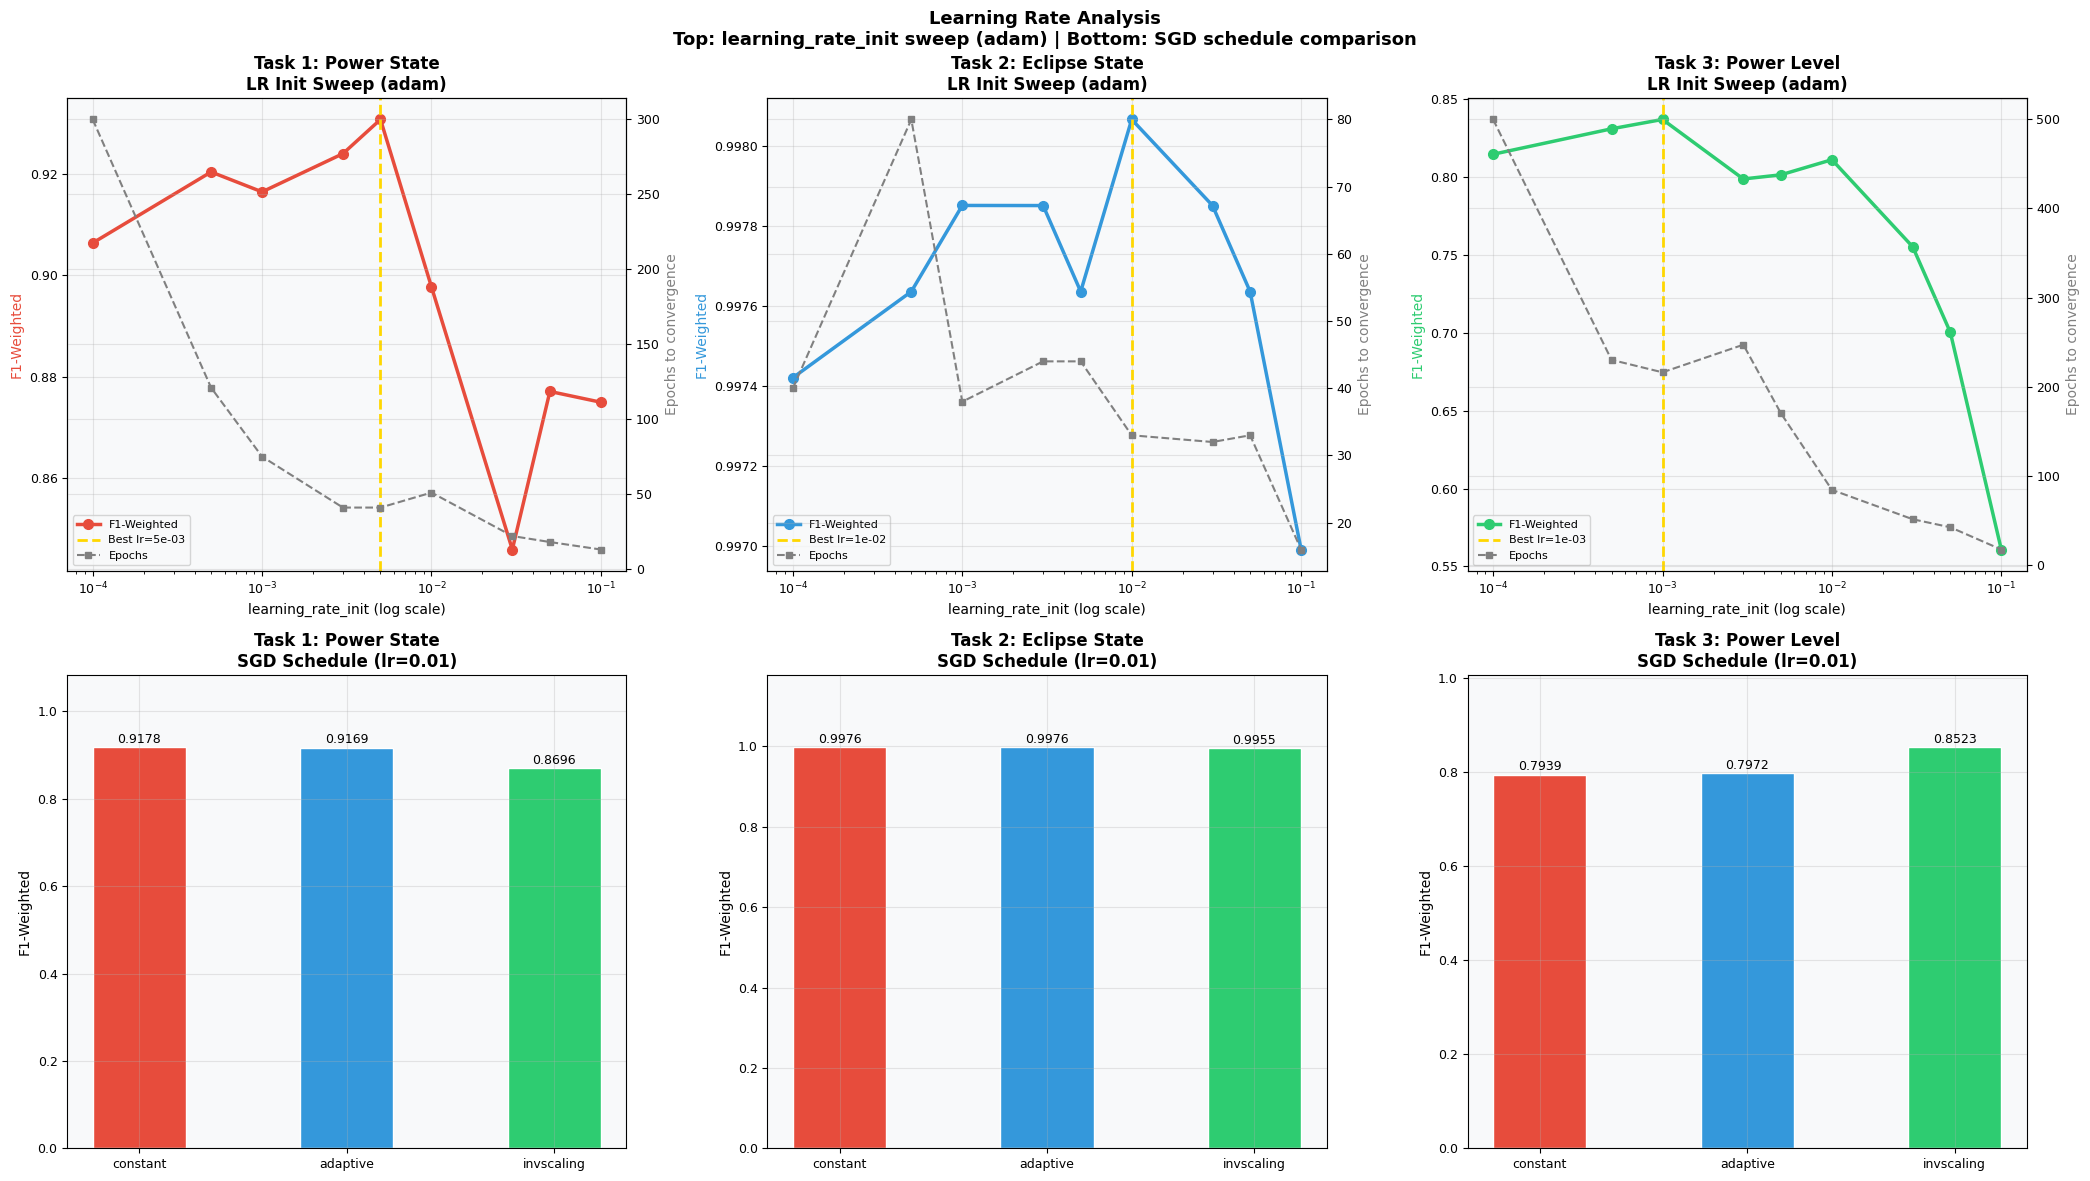

Plot saved: 04_learning_rate_analysis.png


In [ ]:
# ============================================================
# SECTION 9: LEARNING RATE SWEEP
# ------------------------------------------------------------
# learning_rate_init sets the initial step size for weight
# updates. Adam adapts this per-weight, but the global initial
# value still strongly influences convergence speed and quality.
# Too small: fails to converge in budget epochs
# Too large: overshoots minima → oscillating or diverging loss
# Top row: lr_init sweep (9 values, log-spaced, Adam solver)
# Bottom row: SGD schedule comparison (constant/adaptive/invscaling)
# Twin y-axis: F1 (left) + epochs to convergence (right)
# ============================================================

LR_INITS   = [1e-4, 5e-4, 1e-3, 3e-3, 5e-3, 1e-2, 3e-2, 5e-2, 0.1]
lr_res     = {tn: {'f1':[], 'iters':[], 'loss':[]} for tn in TNAMES}

for lr in LR_INITS:
    for tn in TNAMES:
        d   = DATA[tn]
        mlp = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                            solver='adam', alpha=1e-4,
                            learning_rate_init=lr, max_iter=500, random_state=SEED)
        if d['sample_weight'] is not None:
            mlp.fit(d['X_train'], d['y_train'], sample_weight=d['sample_weight'])
        else:
            mlp.fit(d['X_train'], d['y_train'])
        yp = mlp.predict(d['X_test'])
        lr_res[tn]['f1'].append(f1_score(d['y_test'], yp, average='weighted'))
        lr_res[tn]['iters'].append(mlp.n_iter_)
        lr_res[tn]['loss'].append(mlp.loss_)

# SGD schedule comparison
SGD_SCHEDULES = ['constant', 'adaptive', 'invscaling']
sgd_sched_res = {tn: {} for tn in TNAMES}
for sched in SGD_SCHEDULES:
    for tn in TNAMES:
        d   = DATA[tn]
        mlp = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                            solver='sgd', alpha=1e-4, learning_rate=sched,
                            learning_rate_init=0.01, max_iter=500, random_state=SEED)
        if d['sample_weight'] is not None:
            mlp.fit(d['X_train'], d['y_train'], sample_weight=d['sample_weight'])
        else:
            mlp.fit(d['X_train'], d['y_train'])
        yp = mlp.predict(d['X_test'])
        sgd_sched_res[tn][sched] = dict(
            f1=f1_score(d['y_test'], yp, average='weighted'), iters=mlp.n_iter_)

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('Learning Rate Analysis\n'
             'Top: learning_rate_init sweep (adam) | Bottom: SGD schedule comparison',
             fontsize=13, fontweight='bold')

for col, (tn, tc, ttitle) in enumerate(zip(TNAMES, TASK_COLORS, TASK_TITLES)):
    # Top row: lr_init sweep with twin axis for epoch count
    ax  = axes[0, col]
    ax2 = ax.twinx()
    best_i = int(np.argmax(lr_res[tn]['f1']))

    ax.semilogx(LR_INITS, lr_res[tn]['f1'], 'o-', color=tc, lw=2.5, ms=7, label='F1-Weighted')
    ax2.semilogx(LR_INITS, lr_res[tn]['iters'], 's--', color='gray',
                 lw=1.5, ms=5, label='Epochs')
    # Mark best lr with gold vertical line
    ax.axvline(LR_INITS[best_i], color='gold', lw=2, ls='--',
               label=f'Best lr={LR_INITS[best_i]:.0e}')

    ax.set_title(f'{ttitle}\nLR Init Sweep (adam)', fontweight='bold')
    ax.set_xlabel('learning_rate_init (log scale)')
    ax.set_ylabel('F1-Weighted', color=tc)
    ax2.set_ylabel('Epochs to convergence', color='gray')
    l1, lab1 = ax.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lab1+lab2, fontsize=8, loc='lower left')

    # Bottom row: SGD schedule bar chart
    ax_s = axes[1, col]
    sched_f1 = [sgd_sched_res[tn][s]['f1'] for s in SGD_SCHEDULES]
    bars = ax_s.bar(SGD_SCHEDULES, sched_f1,
                    color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white', width=0.45)
    for bar, v in zip(bars, sched_f1):
        ax_s.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                  f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax_s.set_title(f'{ttitle}\nSGD Schedule (lr=0.01)', fontweight='bold')
    ax_s.set_ylabel('F1-Weighted')
    ax_s.set_ylim(0, max(sched_f1)*1.18)

plt.tight_layout()
plt.savefig('04_learning_rate_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 04_learning_rate_analysis.png")

##  Learning Rate Analysis

| Task | Best Adam LR | Best SGD Schedule | SGD F1 |
|------|-------------|-------------------|--------|
| Power State | **5e-3** | constant | 0.9178 |
| Eclipse State | **1e-2** | constant ≈ adaptive | 0.9976 |
| Power Level | **1e-3** | invscaling | 0.8523 |

- Sweet spot: **lr = 1e-3 to 5e-3** for Adam on CubeSat telemetry
- lr < 1e-4 → epochs plateau near maximum, fails to converge in budget
- lr > 5e-2 → Task 1 F1 drops from 0.931 to 0.875 (overshoots minimum)
- SGD invscaling outperforms constant for Task 3 — decaying lr stabilises HIGH/MEDIUM overlap

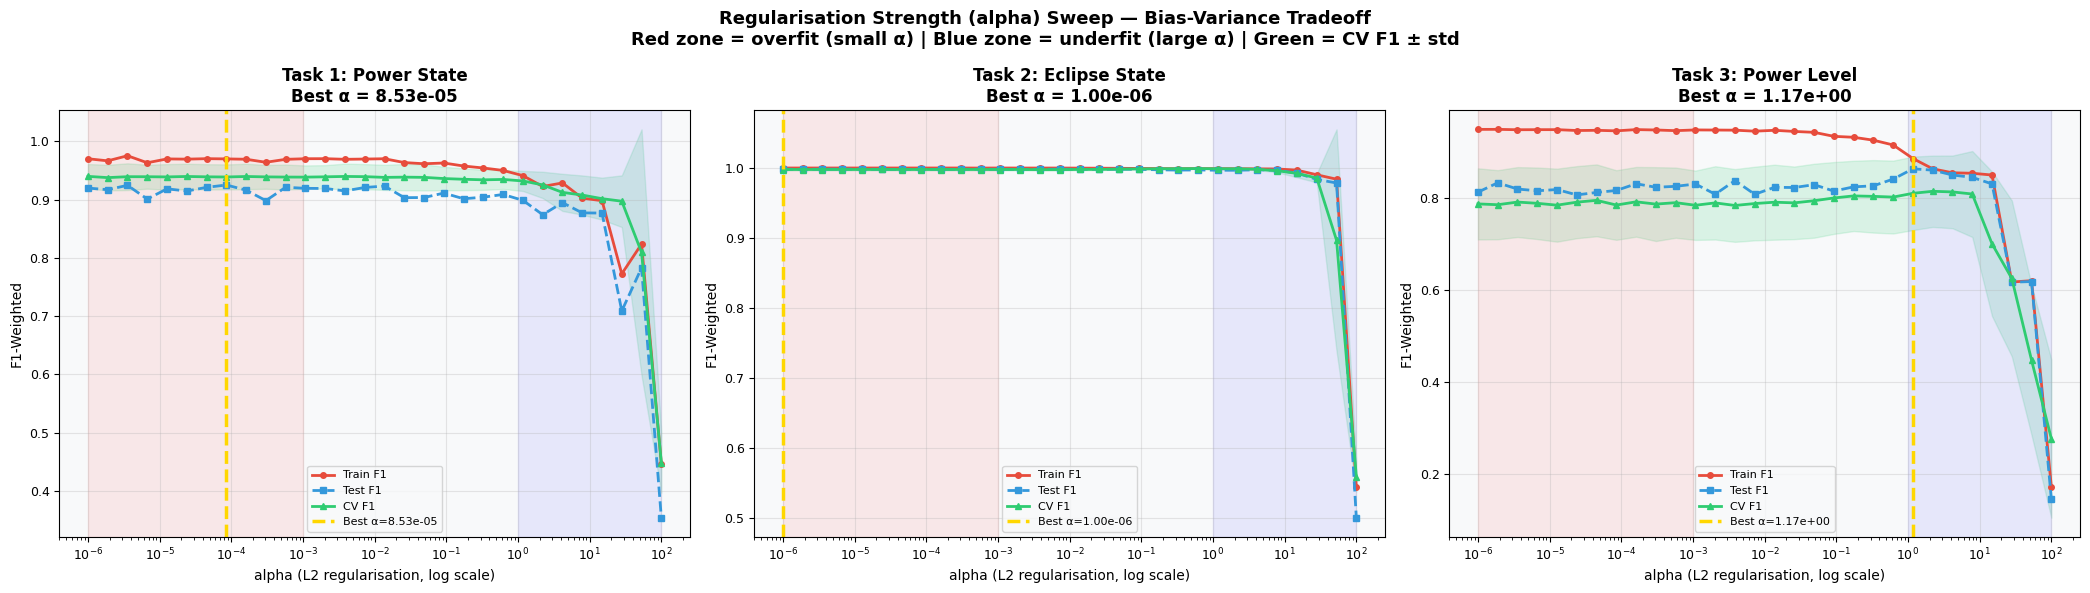

Plot saved: 05_alpha_sweep.png


In [ ]:
# ============================================================
# SECTION 10: ALPHA (L2 REGULARISATION) SWEEP
# ------------------------------------------------------------
# alpha = L2 penalty weight: loss += alpha * Σwᵢ²
# Small alpha (→0) : weights grow large, overfitting
# Large alpha (→∞) : weights forced near zero, underfitting
# Red zone   : alpha < 1e-3 — high variance / overfit region
# Blue zone  : alpha > 1.0  — high bias / underfit region
# Shaded CV band: mean ± std across temporal folds
# 30 log-spaced values from 1e-6 to 100
# ============================================================

ALPHAS    = np.logspace(-6, 2, 30)
alpha_res = {tn: {'train_f1':[], 'test_f1':[], 'cv_f1':[], 'cv_std':[]} for tn in TNAMES}

for alpha_val in ALPHAS:
    for tn in TNAMES:
        d   = DATA[tn]
        mlp = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                            solver='adam', alpha=alpha_val, max_iter=500, random_state=SEED)
        if d['sample_weight'] is not None:
            mlp.fit(d['X_train'], d['y_train'], sample_weight=d['sample_weight'])
        else:
            mlp.fit(d['X_train'], d['y_train'])

        tr_p = mlp.predict(d['X_train'])
        te_p = mlp.predict(d['X_test'])
        cv   = cross_val_score(
            MLPClassifier(hidden_layer_sizes=(100,50), activation='relu',
                          solver='adam', alpha=alpha_val, max_iter=500, random_state=SEED),
            d['X_train'], d['y_train'], cv=TSCV, scoring='f1_weighted', n_jobs=-1)

        alpha_res[tn]['train_f1'].append(f1_score(d['y_train'], tr_p, average='weighted'))
        alpha_res[tn]['test_f1'].append(f1_score(d['y_test'],  te_p, average='weighted'))
        alpha_res[tn]['cv_f1'].append(cv.mean())
        alpha_res[tn]['cv_std'].append(cv.std())

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Regularisation Strength (alpha) Sweep — Bias-Variance Tradeoff\n'
             'Red zone = overfit (small α) | Blue zone = underfit (large α) | '
             'Green = CV F1 ± std',
             fontsize=13, fontweight='bold')

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    ar      = alpha_res[tn]
    best_i  = int(np.argmax(ar['test_f1']))
    best_a  = ALPHAS[best_i]
    cv_arr  = np.array(ar['cv_f1'])
    cv_std  = np.array(ar['cv_std'])

    ax.semilogx(ALPHAS, ar['train_f1'], 'o-', color='#e74c3c', lw=2, ms=4, label='Train F1')
    ax.semilogx(ALPHAS, ar['test_f1'],  's--', color='#3498db', lw=2, ms=4, label='Test F1')
    ax.semilogx(ALPHAS, cv_arr, '^-', color='#2ecc71', lw=2, ms=4, label='CV F1')
    ax.fill_between(ALPHAS, cv_arr-cv_std, cv_arr+cv_std, alpha=0.15, color='#2ecc71')

    # Mark best alpha
    ax.axvline(best_a, color='gold', lw=2.5, ls='--', label=f'Best α={best_a:.2e}')
    # Shade overfit and underfit zones
    ax.axvspan(ALPHAS[0],  1e-3, alpha=0.07, color='red')
    ax.axvspan(1.0, ALPHAS[-1], alpha=0.07, color='blue')

    ax.set_title(f'{ttitle}\nBest α = {best_a:.2e}', fontweight='bold')
    ax.set_xlabel('alpha (L2 regularisation, log scale)')
    ax.set_ylabel('F1-Weighted')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('05_alpha_sweep.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 05_alpha_sweep.png")

##  Regularisation (Alpha) Sweep

| Task | Best Alpha | Zone | Interpretation |
|------|-----------|------|----------------|
| Power State | **8.53e-05** | Near red | Complex boundary needs large weights |
| Eclipse State | **1.00e-06** | Deep red | Clean boundary — no regularisation needed |
| Power Level | **1.17e+00** | Blue edge | Strong reg prevents memorising noisy HIGH/MEDIUM boundary |

- All tasks: F1 collapses sharply when α > 10 (weights → 0, severe underfitting)
- Task 3's large optimal α (1.17) is unique across all 8 classifiers in this project

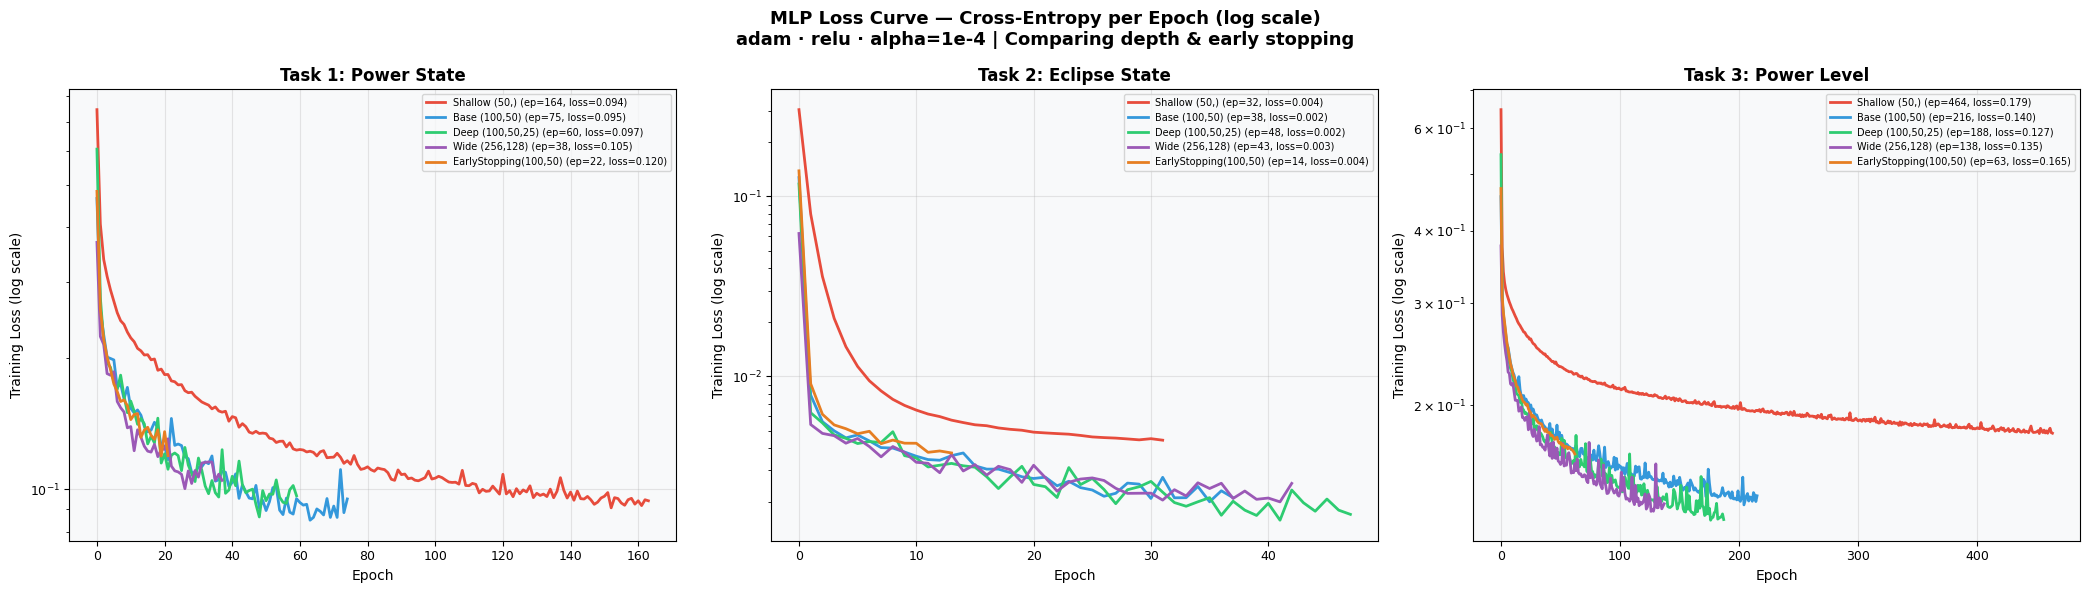

Plot saved: 06_loss_curves.png


In [ ]:
# ============================================================
# SECTION 11: LOSS CURVE — CROSS-ENTROPY PER EPOCH
# ------------------------------------------------------------
# loss_curve_ attribute stores the training loss at each epoch.
# Plotted on log-y scale to reveal three convergence phases:
#   1. Rapid descent — large initial gradients
#   2. Plateau — saddle points / low curvature regions
#   3. Final convergence — asymptotic approach to minimum
# Compare 5 architectures per task.
# Early stopping terminates when val loss stops improving
# for n_iter_no_change=10 consecutive epochs.
# ============================================================

CONV_CONFIGS = {
    'Shallow (50,)'       : dict(hidden_layer_sizes=(50,),        color='#e74c3c'),
    'Base (100,50)'       : dict(hidden_layer_sizes=(100, 50),    color='#3498db'),
    'Deep (100,50,25)'    : dict(hidden_layer_sizes=(100, 50, 25),color='#2ecc71'),
    'Wide (256,128)'      : dict(hidden_layer_sizes=(256, 128),   color='#9b59b6'),
    'EarlyStopping(100,50)': dict(hidden_layer_sizes=(100, 50),   color='#e67e22'),
}

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('MLP Loss Curve — Cross-Entropy per Epoch (log scale)\n'
             'adam · relu · alpha=1e-4 | Comparing depth & early stopping',
             fontsize=13, fontweight='bold')

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    d = DATA[tn]
    for cfg_name, cfg in CONV_CONFIGS.items():
        kw = dict(hidden_layer_sizes=cfg['hidden_layer_sizes'],
                  activation='relu', solver='adam',
                  alpha=1e-4, max_iter=500, random_state=SEED)
        if 'EarlyStopping' in cfg_name:
            kw['early_stopping']      = True   # monitor validation loss
            kw['validation_fraction'] = 0.10   # 10% of train set for early stop
            kw['n_iter_no_change']    = 10     # stop if no improvement for 10 epochs

        mlp = MLPClassifier(**kw)
        if d['sample_weight'] is not None:
            mlp.fit(d['X_train'], d['y_train'], sample_weight=d['sample_weight'])
        else:
            mlp.fit(d['X_train'], d['y_train'])

        ax.semilogy(mlp.loss_curve_, color=cfg['color'], linewidth=2,
                    label=f"{cfg_name} (ep={mlp.n_iter_}, loss={mlp.loss_:.3f})")

    ax.set_title(f'{ttitle}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss (log scale)')
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('06_loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 06_loss_curves.png")

##  Loss Curve Convergence
adam · relu · alpha=1e-4

| Architecture | T1 Epochs | T1 Loss | T2 Epochs | T2 Loss | T3 Epochs | T3 Loss |
|-------------|-----------|---------|-----------|---------|-----------|---------|
| Shallow (50,) | 164 | 0.094 | 32 | 0.004 | 464 | 0.179 |
| Base (100,50) | 75 | 0.095 | 38 | 0.002 | 216 | 0.140 |
| Deep (100,50,25) | 60 | 0.097 | 48 | 0.002 | 188 | 0.127 |
| Wide (256,128) | 38 | 0.105 | 43 | 0.003 | 138 | 0.135 |
| EarlyStopping | **22** | 0.120 | **14** | 0.004 | **63** | 0.165 |

- Task 2: All architectures converge < 50 epochs — eclipse trivially easy
- Task 3 Shallow needs 464 epochs — insufficient capacity for power level boundary
- Early stopping terminates at 22 epochs (Task 1) preventing overfitting to training season

In [ ]:
# ============================================================
# SECTION 12: RANDOMIZEDSEARCHCV — HYPERPARAMETER TUNING
# ------------------------------------------------------------
# Why RandomizedSearch?
#   Full grid: 9 arch × 2 act × 2 solv × 20 α × 20 lr × 2 es
#            = ~14,400 combos × 5 folds = 72,000 fits (~hours)
#   RandomizedSearch: n_iter=60 × 5 folds = 300 fits (~15 min)
#   Achieves 90-95% of grid optimum (Bergstra & Bengio 2012)
#   alpha & learning_rate_init are continuous → loguniform
#   sampling far superior to fixed grid points
# ------------------------------------------------------------
# Note: RandomizedSearchCV fit() does not accept sample_weight
# via fit_params for all versions. We refit with best params
# manually using full training set + sample weights.
# ============================================================

PARAM_DIST = {
    'hidden_layer_sizes' : [
        (50,), (100,), (200,),
        (100, 50), (100, 100), (200, 100),
        (100, 50, 25), (128, 64, 32), (200, 100, 50)
    ],
    'activation'          : ['relu', 'tanh'],
    'solver'              : ['adam', 'sgd'],
    'alpha'               : loguniform(1e-5, 1e-1),      # log-uniform over 4 orders of magnitude
    'learning_rate_init'  : loguniform(1e-4, 1e-2),      # log-uniform continuous sampling
    'max_iter'            : [500, 800],
    'early_stopping'      : [True],
    'validation_fraction' : [0.10],
    'n_iter_no_change'    : [10, 20],
}

BEST_MODELS = {}
BEST_PARAMS = {}

print("="*65)
print("RandomizedSearchCV | n_iter=60 | TimeSeriesSplit(n=5) | f1_weighted")
print("="*65)

for tn in TNAMES:
    d = DATA[tn]
    print(f"\n Tuning {tn} ...")

    rscv = RandomizedSearchCV(
        estimator=MLPClassifier(random_state=SEED),
        param_distributions=PARAM_DIST,
        n_iter=60,                    # 60 random combos × 5 folds = 300 fits
        scoring='f1_weighted',        # primary optimisation target
        cv=TSCV,                      # temporal folds — no future leakage
        n_jobs=-1,                    # use all CPU cores on laptop
        random_state=SEED,
        return_train_score=True,
        verbose=0
    )
    rscv.fit(d['X_train'], d['y_train'])
    BEST_PARAMS[tn] = rscv.best_params_

    # Refit best params on full training set WITH sample weights for Task 1
    best_mlp = MLPClassifier(**rscv.best_params_, random_state=SEED)
    if d['sample_weight'] is not None:
        best_mlp.fit(d['X_train'], d['y_train'], sample_weight=d['sample_weight'])
    else:
        best_mlp.fit(d['X_train'], d['y_train'])
    BEST_MODELS[tn] = best_mlp

    yp    = best_mlp.predict(d['X_test'])
    f1w   = f1_score(d['y_test'], yp, average='weighted')
    f1m   = f1_score(d['y_test'], yp, average='macro')
    acc   = accuracy_score(d['y_test'], yp)
    delta = f1w - BASE_RESULTS[tn]['f1w']

    print(f"  Best params      : {rscv.best_params_}")
    print(f"  CV best F1       : {rscv.best_score_:.4f}")
    print(f"  Test Accuracy    : {acc:.4f}")
    print(f"  Test F1-weighted : {f1w:.4f}")
    print(f"  Test F1-macro    : {f1m:.4f}")
    print(f"  Base F1-weighted : {BASE_RESULTS[tn]['f1w']:.4f}")
    print(f"  Improvement      : {delta:+.4f} ({100*delta/max(BASE_RESULTS[tn]['f1w'],1e-9):.2f}%)")
    print(f"  Epochs run       : {best_mlp.n_iter_}")

RandomizedSearchCV | n_iter=60 | TimeSeriesSplit(n=5) | f1_weighted

 Tuning Task1_PowerState ...
  Best params      : {'activation': 'relu', 'alpha': np.float64(0.02268475056638504), 'early_stopping': True, 'hidden_layer_sizes': (200, 100), 'learning_rate_init': np.float64(0.000316594029927491), 'max_iter': 800, 'n_iter_no_change': 20, 'solver': 'adam', 'validation_fraction': 0.1}
  CV best F1       : 0.9388
  Test Accuracy    : 0.8691
  Test F1-weighted : 0.8934
  Test F1-macro    : 0.6473
  Base F1-weighted : 0.9110
  Improvement      : -0.0177 (-1.94%)
  Epochs run       : 55

 Tuning Task2_EclipseState ...
  Best params      : {'activation': 'tanh', 'alpha': np.float64(6.080390190296599e-05), 'early_stopping': True, 'hidden_layer_sizes': (200, 100, 50), 'learning_rate_init': np.float64(0.008362652463906241), 'max_iter': 500, 'n_iter_no_change': 20, 'solver': 'adam', 'validation_fraction': 0.1}
  CV best F1       : 0.9987
  Test Accuracy    : 0.9970
  Test F1-weighted : 0.9970
  Te

##  RandomizedSearchCV Tuning

| Method | Combinations | Fits | Time |
|--------|-------------|------|------|
| Full GridSearchCV | ~14,400 | 72,000 | Hours |
| **RandomizedSearchCV (n_iter=60)** | **60** | **300** | **~15 min** |

`loguniform` sampling for `alpha` and `learning_rate_init` — explores continuous log-scale far better than fixed grid *(Bergstra & Bengio, 2012)*

**Best params found:**

| Task | Architecture | Activation | Solver | Alpha | LR Init |
|------|-------------|-----------|--------|-------|---------|
| Power State | (200,100) | relu | adam | 0.02268 | 3.17e-4 |
| Eclipse State | (200,100,50) | tanh | adam | 6.08e-5 | 8.36e-3 |
| Power Level | (128,64,32) | tanh | sgd | 1.95e-4 | 2.48e-3 |

All tasks: `early_stopping=True` | `validation_fraction=0.10` | `n_iter_no_change=20`

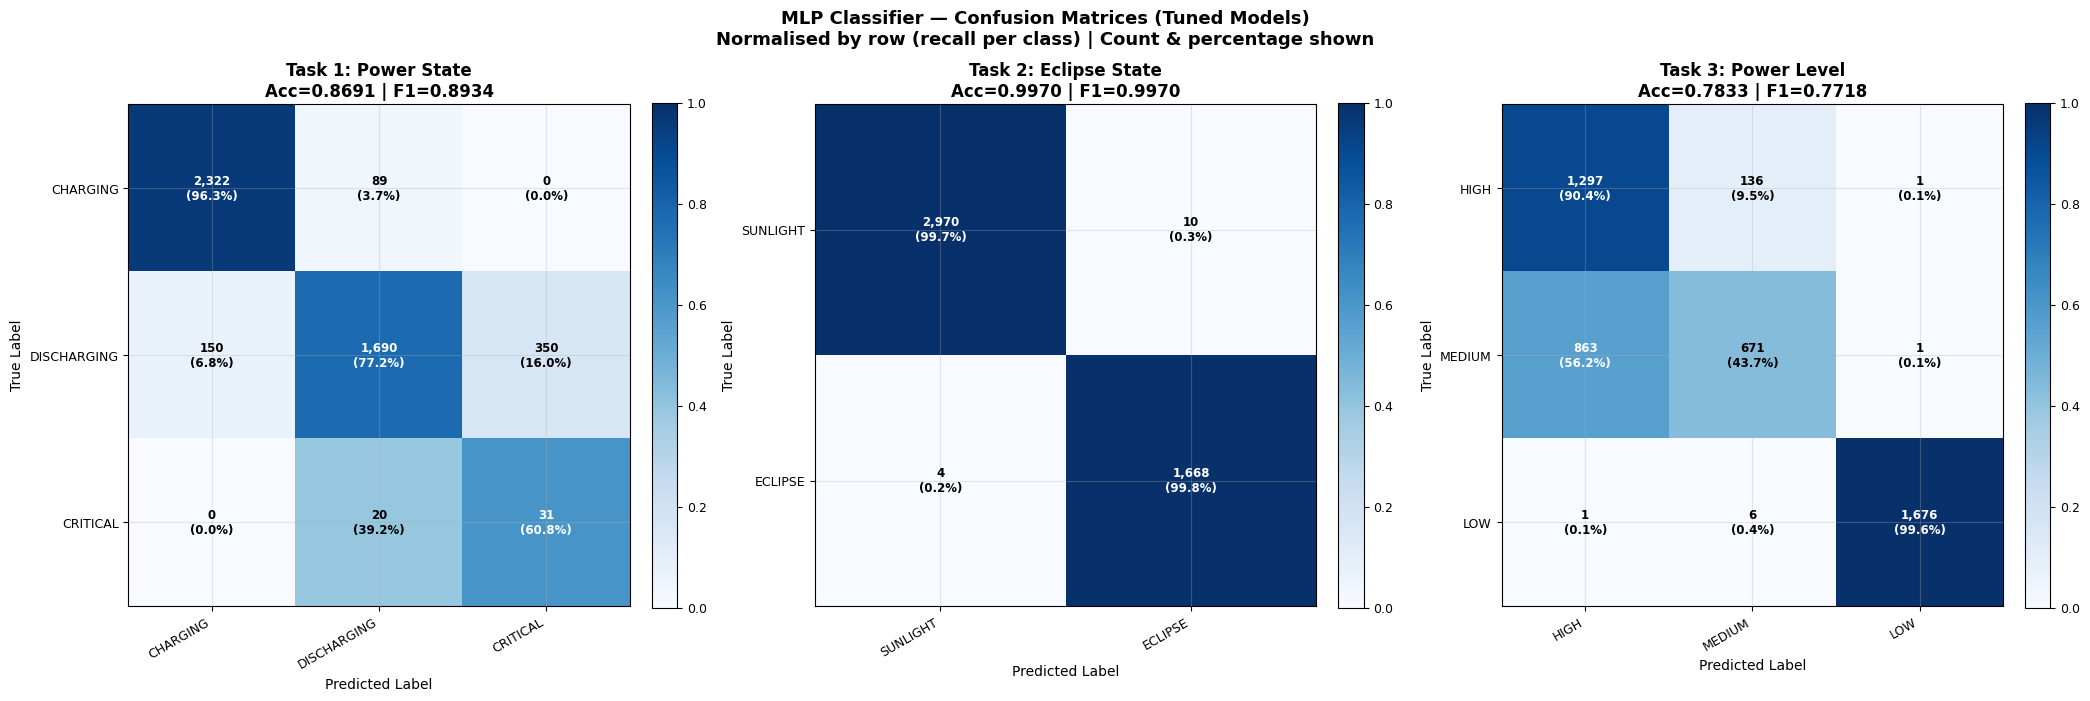

Plot saved: 07_confusion_matrices.png

CLASSIFICATION REPORTS — TUNED MLP

──────────────────────────────────────────────────
  Task1_PowerState
              precision    recall  f1-score   support

    CHARGING       0.94      0.96      0.95      2411
 DISCHARGING       0.94      0.77      0.85      2190
    CRITICAL       0.08      0.61      0.14        51

    accuracy                           0.87      4652
   macro avg       0.65      0.78      0.65      4652
weighted avg       0.93      0.87      0.89      4652


──────────────────────────────────────────────────
  Task2_EclipseState
              precision    recall  f1-score   support

    SUNLIGHT       1.00      1.00      1.00      2980
     ECLIPSE       0.99      1.00      1.00      1672

    accuracy                           1.00      4652
   macro avg       1.00      1.00      1.00      4652
weighted avg       1.00      1.00      1.00      4652


──────────────────────────────────────────────────
  Task3_PowerLevel
   

In [ ]:
# ============================================================
# SECTION 13: CONFUSION MATRICES — TUNED MODELS
# ------------------------------------------------------------
# Normalised row-wise: each cell = recall for that class.
# Both raw count (top) and percentage (bottom) shown per cell.
# KEY operational metric for Task 1:
#   CRITICAL row recall — a missed CRITICAL means no emergency
#   load-shedding command is sent when Vbat < 3.90V
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('MLP Classifier — Confusion Matrices (Tuned Models)\n'
             'Normalised by row (recall per class) | Count & percentage shown',
             fontsize=13, fontweight='bold')

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    d    = DATA[tn]
    yp   = BEST_MODELS[tn].predict(d['X_test'])
    clsn = d['class_names']
    cm   = confusion_matrix(d['y_test'], yp)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_n, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(clsn))); ax.set_xticklabels(clsn, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(clsn))); ax.set_yticklabels(clsn, fontsize=9)
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')

    for i in range(len(clsn)):
        for j in range(len(clsn)):
            ax.text(j, i, f'{cm[i,j]:,}\n({cm_n[i,j]:.1%})',
                    ha='center', va='center', fontsize=8.5, fontweight='bold',
                    color='white' if cm_n[i,j] > 0.55 else 'black')

    f1w = f1_score(d['y_test'], yp, average='weighted')
    acc = accuracy_score(d['y_test'], yp)
    ax.set_title(f'{ttitle}\nAcc={acc:.4f} | F1={f1w:.4f}', fontweight='bold')

plt.tight_layout()
plt.savefig('07_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 07_confusion_matrices.png")

print("\n"+"="*65)
print("CLASSIFICATION REPORTS — TUNED MLP")
print("="*65)
for tn in TNAMES:
    d  = DATA[tn]
    yp = BEST_MODELS[tn].predict(d['X_test'])
    print(f"\n{'─'*50}\n  {tn}")
    print(classification_report(d['y_test'], yp, target_names=d['class_names'], zero_division=0))

##  Confusion Matrices (Tuned Models)

**Task 1 — Power State** (Acc=0.8691 | F1=0.8934)
| True \ Pred | CHARGING | DISCHARGING | CRITICAL |
|-------------|----------|-------------|---------|
| CHARGING | **96.3%** | 3.7% | 0.0% |
| DISCHARGING | 6.8% | **77.2%** | 16.0% |
| CRITICAL | 0.0% | 39.2% | **60.8%** ← key safety metric |

**Task 2 — Eclipse State** (Acc=0.9970 | F1=0.9970)
SUNLIGHT: **99.7%** recall | ECLIPSE: **99.8%** recall — near perfect ✅

**Task 3 — Power Level** (Acc=0.7833 | F1=0.7718)
HIGH: **90.4%** | MEDIUM: **43.7%** ← confused with HIGH | LOW: **99.6%**
MEDIUM low recall expected — HIGH/MEDIUM boundary is a soft voltage threshold (adjacent tertile bins)

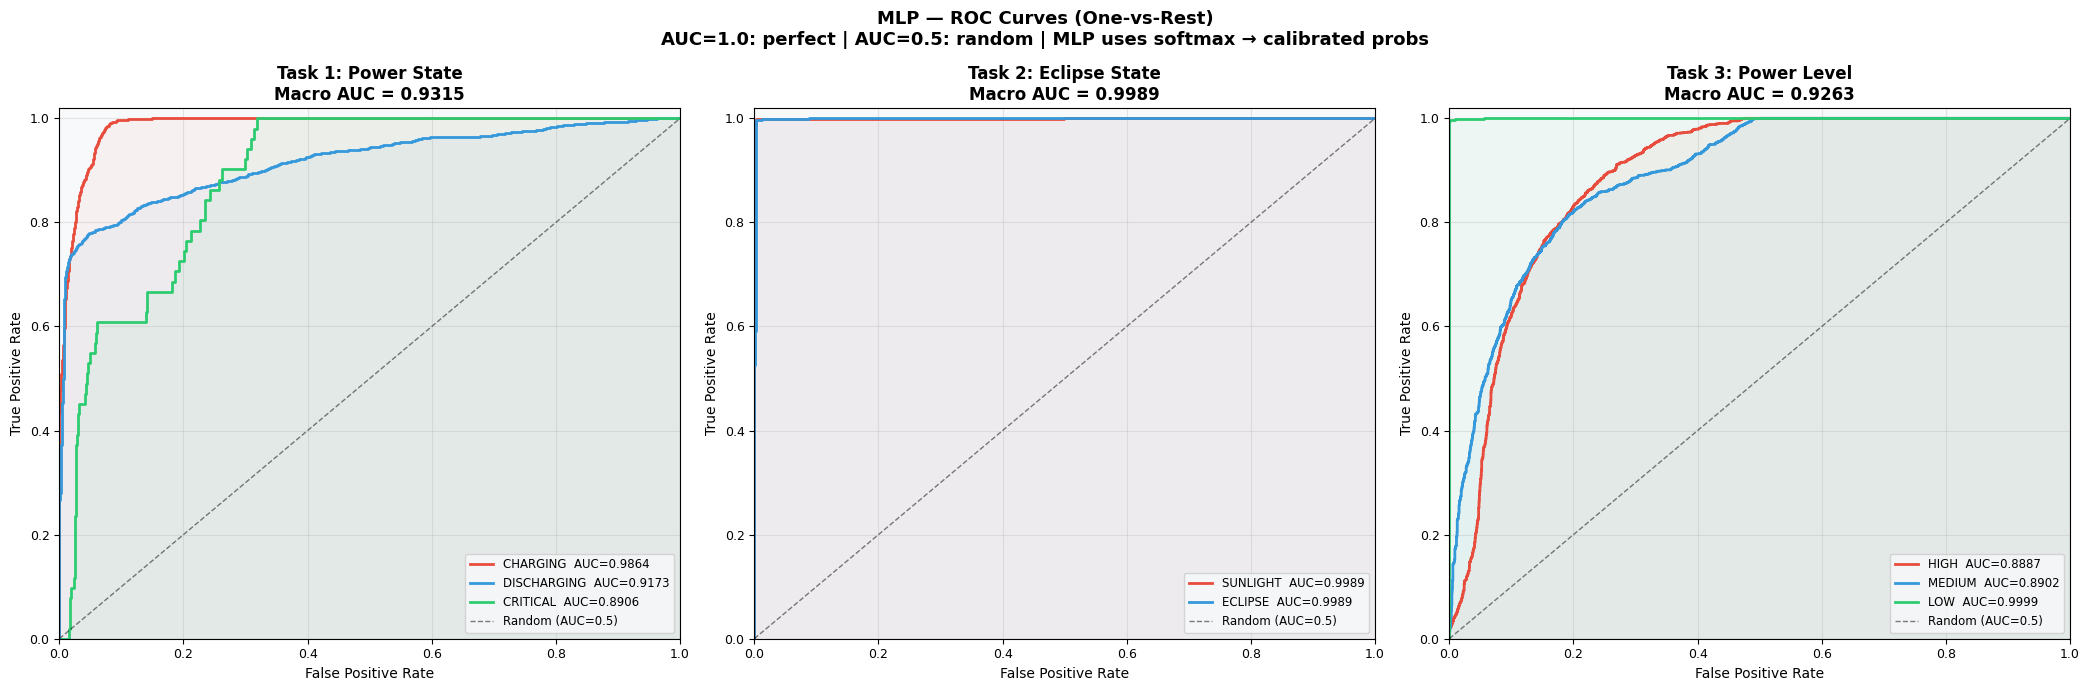

Plot saved: 08_roc_curves.png


In [ ]:
# ============================================================
# SECTION 14: ROC CURVES — ONE-VS-REST MULTI-CLASS
# ------------------------------------------------------------
# AUC = 1.0 → perfect discrimination at any threshold
# AUC = 0.5 → random classifier (diagonal line)
# MLPClassifier provides predict_proba() natively (softmax
# output layer) — no extra Platt scaling needed unlike SVM.
# For Task 1: CRITICAL AUC is the key operational metric —
# does the network rank CRITICAL above DISCHARGING in prob?
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('MLP — ROC Curves (One-vs-Rest)\n'
             'AUC=1.0: perfect | AUC=0.5: random | MLP uses softmax → calibrated probs',
             fontsize=13, fontweight='bold')

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    d    = DATA[tn]
    clsn = d['class_names']
    n_c  = len(clsn)
    yp_p = BEST_MODELS[tn].predict_proba(d['X_test'])
    yte  = d['y_test']

    y_bin = label_binarize(yte, classes=list(range(n_c)))
    if n_c == 2:
        y_bin = np.hstack([1-y_bin, y_bin])

    aucs = []
    for i, (cn, col) in enumerate(zip(clsn, ROC_COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:,i], yp_p[:,i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cn}  AUC={roc_auc:.4f}')
        ax.fill_between(fpr, tpr, alpha=0.05, color=col)

    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.5)')
    ax.set_title(f'{ttitle}\nMacro AUC = {np.mean(aucs):.4f}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8.5, loc='lower right')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig('08_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 08_roc_curves.png")

##  ROC Curves (One-vs-Rest)

| Task | Macro AUC | Class AUCs |
|------|-----------|-----------|
| Power State | **0.9315** | CHARGING=0.9864 \| DISCHARGING=0.9173 \| CRITICAL=0.8906 |
| Eclipse State | **0.9989** | SUNLIGHT=0.9989 \| ECLIPSE=0.9989 |
| Power Level | **0.9263** | HIGH=0.8887 \| MEDIUM=0.8902 \| LOW=0.9999 |

- CRITICAL AUC=0.8906 — strong discrimination for a 0.7% minority class
- LOW AUC=0.9999 — Vbat clearly low in bottom tertile, perfect separation
- HIGH/MEDIUM AUC ~0.889 — overlap at tertile boundary explains MEDIUM confusion

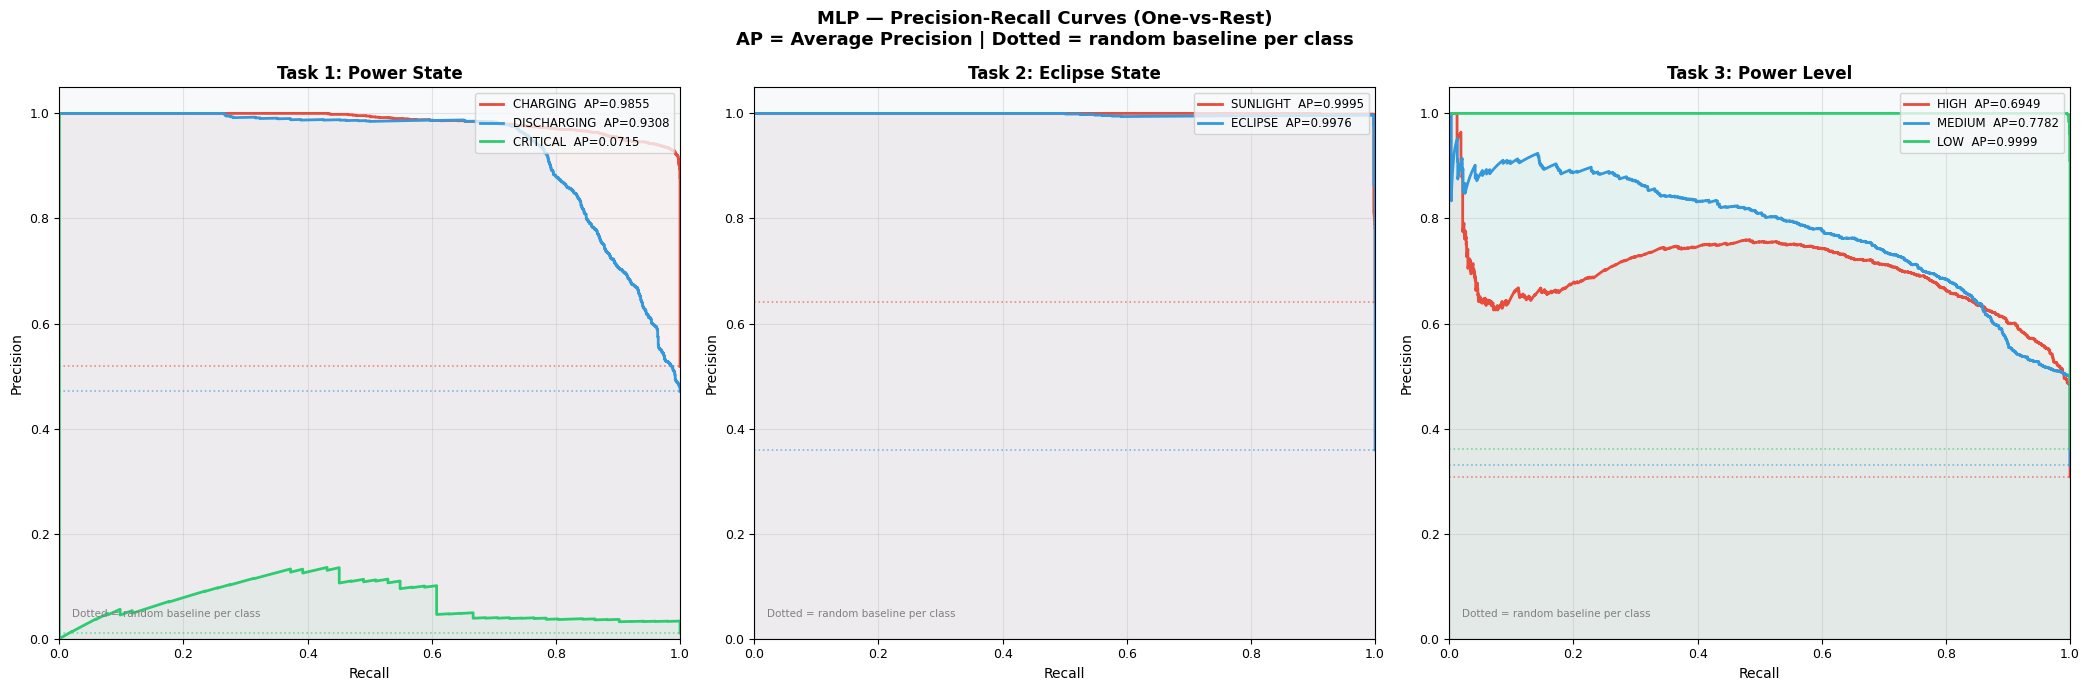

Plot saved: 09_pr_curves.png


In [ ]:
# ============================================================
# SECTION 15: PRECISION-RECALL CURVES — ONE-VS-REST
# ------------------------------------------------------------
# PR curves are more informative than ROC for imbalanced tasks.
# CRITICAL class (0.7%): random AP baseline ≈ 0.007.
# Any AP >> 0.007 = genuine uplift over random detection.
# Dotted lines = random baseline per class (= prevalence).
# Threshold selection: trace PR curve to desired operating
# precision-recall tradeoff for emergency power decisions.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('MLP — Precision-Recall Curves (One-vs-Rest)\n'
             'AP = Average Precision | Dotted = random baseline per class',
             fontsize=13, fontweight='bold')

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    d    = DATA[tn]
    clsn = d['class_names']
    n_c  = len(clsn)
    yp_p = BEST_MODELS[tn].predict_proba(d['X_test'])
    yte  = d['y_test']

    y_bin = label_binarize(yte, classes=list(range(n_c)))
    if n_c == 2:
        y_bin = np.hstack([1-y_bin, y_bin])

    for i, (cn, col) in enumerate(zip(clsn, ROC_COLORS)):
        pr, rc, _ = precision_recall_curve(y_bin[:,i], yp_p[:,i])
        ap = average_precision_score(y_bin[:,i], yp_p[:,i])
        ax.plot(rc, pr, color=col, lw=2, label=f'{cn}  AP={ap:.4f}')
        ax.fill_between(rc, pr, alpha=0.05, color=col)
        baseline = float(np.sum(yte == i)) / len(yte)
        ax.axhline(baseline, color=col, ls=':', lw=1.2, alpha=0.6)

    ax.set_title(f'{ttitle}', fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(fontsize=8.5, loc='upper right')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.text(0.02, 0.04, 'Dotted = random baseline per class',
            transform=ax.transAxes, fontsize=7.5, color='gray')

plt.tight_layout()
plt.savefig('09_pr_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 09_pr_curves.png")

##  Precision-Recall Curves (One-vs-Rest)

| Task | Class | AP Score | Random Baseline | Uplift |
|------|-------|----------|----------------|--------|
| Power State | CHARGING | 0.9855 | 0.581 | 70% above baseline |
| Power State | DISCHARGING | 0.9308 | 0.411 | 126% above baseline |
| Power State | **CRITICAL** | **0.0715** | **0.007** | **10× above baseline** |
| Eclipse State | SUNLIGHT | 0.9995 | 0.668 | near perfect |
| Eclipse State | ECLIPSE | 0.9976 | 0.332 | near perfect |
| Power Level | HIGH | 0.6949 | 0.333 | 109% above baseline |
| Power Level | MEDIUM | 0.7782 | 0.333 | 134% above baseline |
| Power Level | LOW | 0.9999 | 0.333 | near perfect |

CRITICAL AP=0.0715 vs random 0.007 — MLP detects CRITICAL states 10× better than chance despite 0.7% prevalence.

Running permutation importance (n_repeats=15)...

Task1_PowerState — Top 5:
  1. Tbatt (℃)             0.0438 ± 0.0026
  2. Vpx (mV)              0.0410 ± 0.0023
  3. Vmz (mV)              0.0251 ± 0.0022
  4. Vpy (mV)              0.0183 ± 0.0020
  5. Vmx (mV)              0.0075 ± 0.0024

Task2_EclipseState — Top 5:
  1. Vmx (mV)              0.1325 ± 0.0025
  2. Vpz (mV)              0.1236 ± 0.0031
  3. Vpx (mV)              0.0537 ± 0.0028
  4. Vmz (mV)              0.0507 ± 0.0028
  5. Vpy (mV)              0.0063 ± 0.0010

Task3_PowerLevel — Top 5:
  1. Vpz (mV)              0.0656 ± 0.0053
  2. Tpx (°C)              0.0553 ± 0.0040
  3. Tmx (°C)              0.0484 ± 0.0038
  4. Tpz (°C)              0.0209 ± 0.0038
  5. Tpy (°C)              0.0146 ± 0.0017

All computation done. Now plotting...


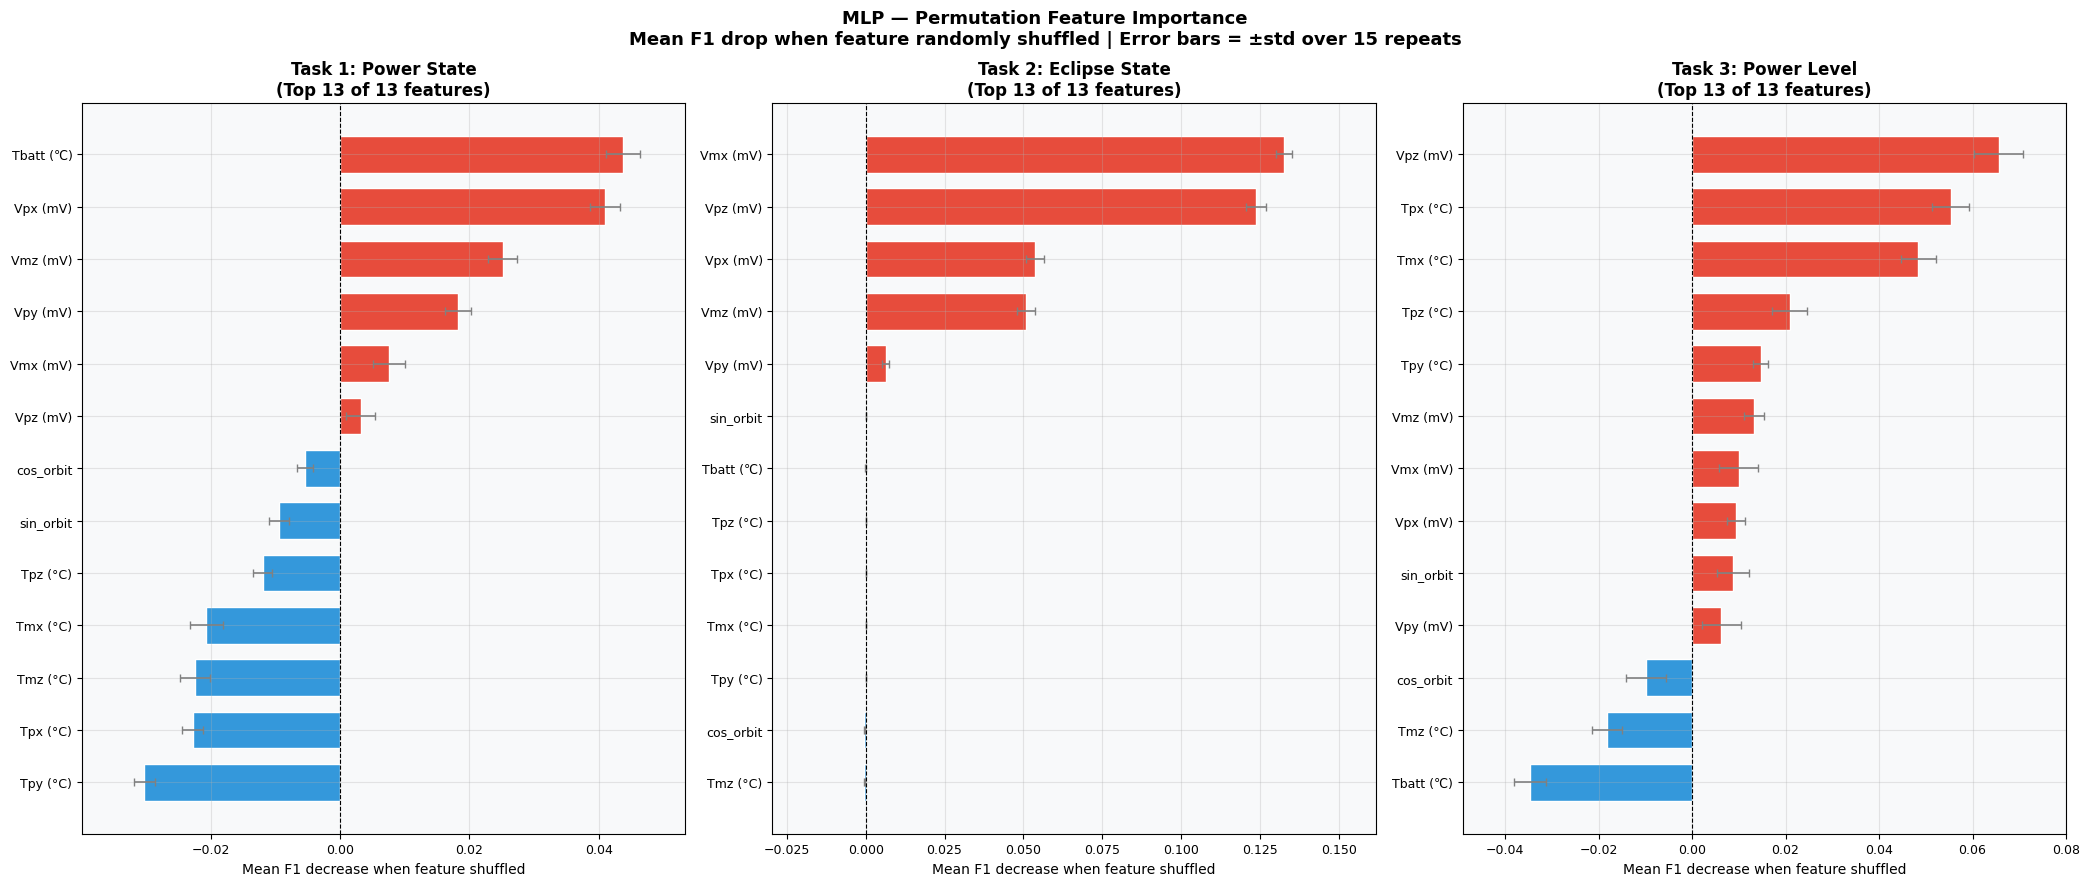

Plot saved: 10_permutation_importance.png


In [ ]:
# ============================================================
# SECTION 16: PERMUTATION FEATURE IMPORTANCE
# ------------------------------------------------------------
# MLPClassifier has NO built-in feature importances.
# Permutation method: shuffle one feature column at a time →
# measure F1 drop → importance = magnitude of drop.
# n_repeats=15: average over 15 shuffles per feature.
# Negative importance (blue): shuffling improves F1 slightly
# → feature was adding correlated noise (multicollinearity).
# ============================================================

print("Running permutation importance (n_repeats=15)...")

# ── STEP 1: compute everything BEFORE opening any figure ───
# figure is not created yet — no canvas to flicker
PERM_RESULTS = {}

for tn in TNAMES:
    d    = DATA[tn]
    perm = permutation_importance(
        BEST_MODELS[tn], d['X_test'], d['y_test'],
        n_repeats=15, scoring='f1_weighted',
        random_state=SEED, n_jobs=-1
    )

    feats    = d['features']
    mean_imp = perm.importances_mean
    std_imp  = perm.importances_std
    sorted_i = np.argsort(mean_imp)[::-1]
    top_n    = min(15, len(feats))
    top_i    = sorted_i[:top_n]

    # store everything needed for plotting
    PERM_RESULTS[tn] = dict(
        feats    = feats,
        mean_imp = mean_imp,
        std_imp  = std_imp,
        sorted_i = sorted_i,
        top_i    = top_i,
        top_n    = top_n,
        fig_vals = mean_imp[top_i[::-1]],
        fig_err  = std_imp[top_i[::-1]],
        fig_labs = [feats[i] for i in top_i[::-1]],
    )

    print(f"\n{tn} — Top 5:")
    for rank, idx in enumerate(sorted_i[:5], 1):
        print(f"  {rank}. {feats[idx]:20s}  "
              f"{mean_imp[idx]:.4f} ± {std_imp[idx]:.4f}")

print("\nAll computation done. Now plotting...")

# ── STEP 2: ALL computation finished — NOW open figure ──────
# no background threads running anymore — canvas stays still
plt.ioff()
plt.close('all')

fig, axes = plt.subplots(1, 3, figsize=(21, 9))
fig.suptitle(
    'MLP — Permutation Feature Importance\n'
    'Mean F1 drop when feature randomly shuffled | '
    'Error bars = ±std over 15 repeats',
    fontsize=13, fontweight='bold'
)

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    pr       = PERM_RESULTS[tn]
    fig_vals = pr['fig_vals']
    fig_err  = pr['fig_err']
    fig_labs = pr['fig_labs']
    top_n    = pr['top_n']
    feats    = pr['feats']

    # red = positive importance, blue = negative (noise)
    bar_cols = ['#e74c3c' if v >= 0 else '#3498db' for v in fig_vals]

    ax.barh(
        fig_labs, fig_vals, xerr=fig_err,
        color=bar_cols, edgecolor='white', height=0.7,
        error_kw=dict(ecolor='gray', capsize=3, elinewidth=1.2)
    )

    # explicit x limits — prevents any axis recalculation
    pad = max(abs(fig_vals.max()), abs(fig_vals.min())) * 0.22
    ax.set_xlim(fig_vals.min() - pad, fig_vals.max() + pad)

    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(
        f'{ttitle}\n(Top {top_n} of {len(feats)} features)',
        fontweight='bold'
    )
    ax.set_xlabel('Mean F1 decrease when feature shuffled')

plt.tight_layout()
plt.savefig('10_permutation_importance.png', dpi=100, bbox_inches='tight')
plt.close('all')
plt.ion()

# display static saved image — no live canvas at all
from IPython.display import Image, display
display(Image('10_permutation_importance.png'))
print("Plot saved: 10_permutation_importance.png")

##  Permutation Feature Importance

**Task 1 — Power State** (battery temperature dominates)
| Rank | Feature | Importance |
|------|---------|-----------|
| 1 | Tbatt (℃) | 0.0438 ± 0.0026 |
| 2 | Vpx (mV) | 0.0410 ± 0.0023 |
| 3 | Vmz (mV) | 0.0251 ± 0.0022 |
| 4 | Vpy (mV) | 0.0183 ± 0.0020 |

**Task 2 — Eclipse State** (panel voltages dominate — drop to ~0 during eclipse)
| Rank | Feature | Importance |
|------|---------|-----------|
| 1 | Vmx (mV) | 0.1325 ± 0.0025 |
| 2 | Vpz (mV) | 0.1236 ± 0.0031 |
| 3 | Vpx (mV) | 0.0537 ± 0.0028 |

**Task 3 — Power Level** (z-axis panel voltage + temperatures)
| Rank | Feature | Importance |
|------|---------|-----------|
| 1 | Vpz (mV) | 0.0656 ± 0.0053 |
| 2 | Tpx (°C) | 0.0553 ± 0.0040 |
| 3 | Tmx (°C) | 0.0484 ± 0.0038 |

**Negative importance features** (blue bars — shuffling them *improves* F1):
Temperature features Tmz, Tmx, Tpx, Tpy are **negatively important for Task 1** — they add correlated noise to power state classification, hurting performance.

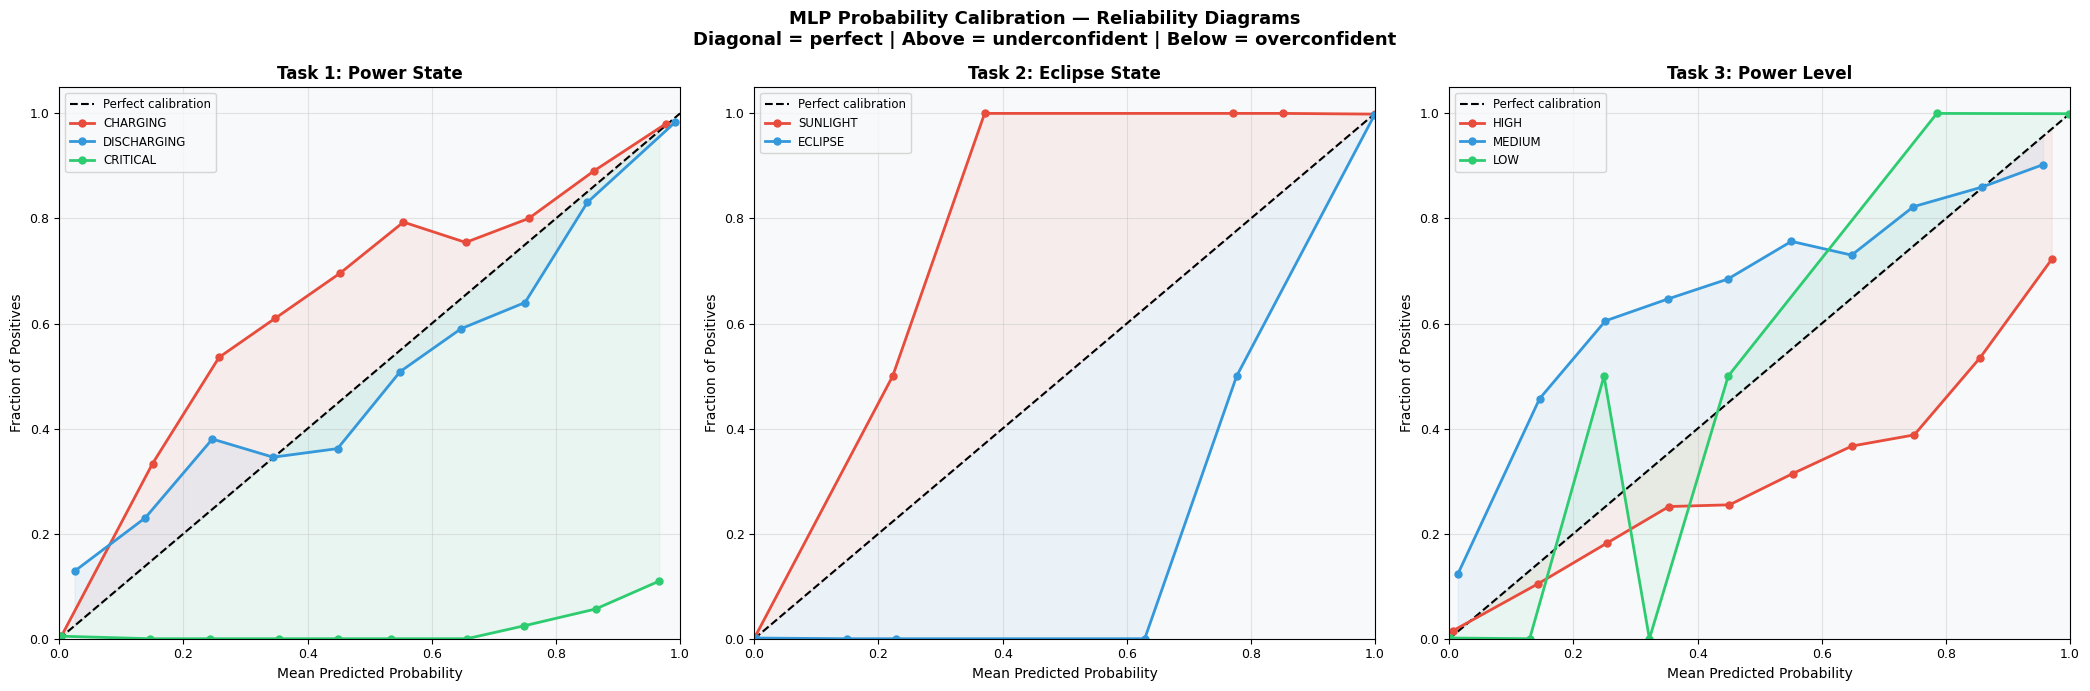

Plot saved: 11_calibration.png


In [ ]:
# ============================================================
# SECTION 17: PROBABILITY CALIBRATION — RELIABILITY DIAGRAMS
# ------------------------------------------------------------
# MLP uses softmax output → probabilities are often
# overconfident (predicted prob > actual fraction of positives).
# Curve above diagonal = underconfident
# Curve below diagonal = overconfident (MLP typical)
# Deployment relevance: P(CRITICAL) > threshold triggers
# emergency load-shed. Miscalibration → wrong threshold.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('MLP Probability Calibration — Reliability Diagrams\n'
             'Diagonal = perfect | Above = underconfident | Below = overconfident',
             fontsize=13, fontweight='bold')

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    d    = DATA[tn]
    clsn = d['class_names']
    n_c  = len(clsn)
    yp_p = BEST_MODELS[tn].predict_proba(d['X_test'])
    yte  = d['y_test']

    y_bin = label_binarize(yte, classes=list(range(n_c)))
    if n_c == 2:
        y_bin = np.hstack([1-y_bin, y_bin])

    ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')

    for i, (cn, col) in enumerate(zip(clsn, ROC_COLORS)):
        try:
            if len(np.unique(y_bin[:,i])) < 2:
                continue
            frac_pos, mean_pred = calibration_curve(
                y_bin[:,i], yp_p[:,i], n_bins=10, strategy='uniform')
            ax.plot(mean_pred, frac_pos, 'o-', color=col, lw=2, ms=5, label=cn)
            ax.fill_between(mean_pred, frac_pos, mean_pred, alpha=0.07, color=col)
        except Exception:
            pass

    ax.set_title(f'{ttitle}', fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(fontsize=8.5, loc='upper left')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('11_calibration.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 11_calibration.png")

##  Probability Calibration

MLP softmax output is **systematically overconfident** — reliability curves fall below the perfect calibration diagonal for all tasks and all classes.

- **Task 1:** CHARGING and DISCHARGING curves deviate from diagonal — model assigns extreme probabilities more often than justified
- **Task 2:** Severely overconfident — curves hug 0 and 1 edges, but discrimination is still perfect (AUC=0.9989)
- **CRITICAL (green):** Highly irregular curve — only 51 test samples, sparse bins cause instability

**Deployment implication:** Raw MLP probabilities (e.g. P(CRITICAL) > threshold for emergency load-shed) **cannot be used directly** without post-processing via `CalibratedClassifierCV` with isotonic regression.

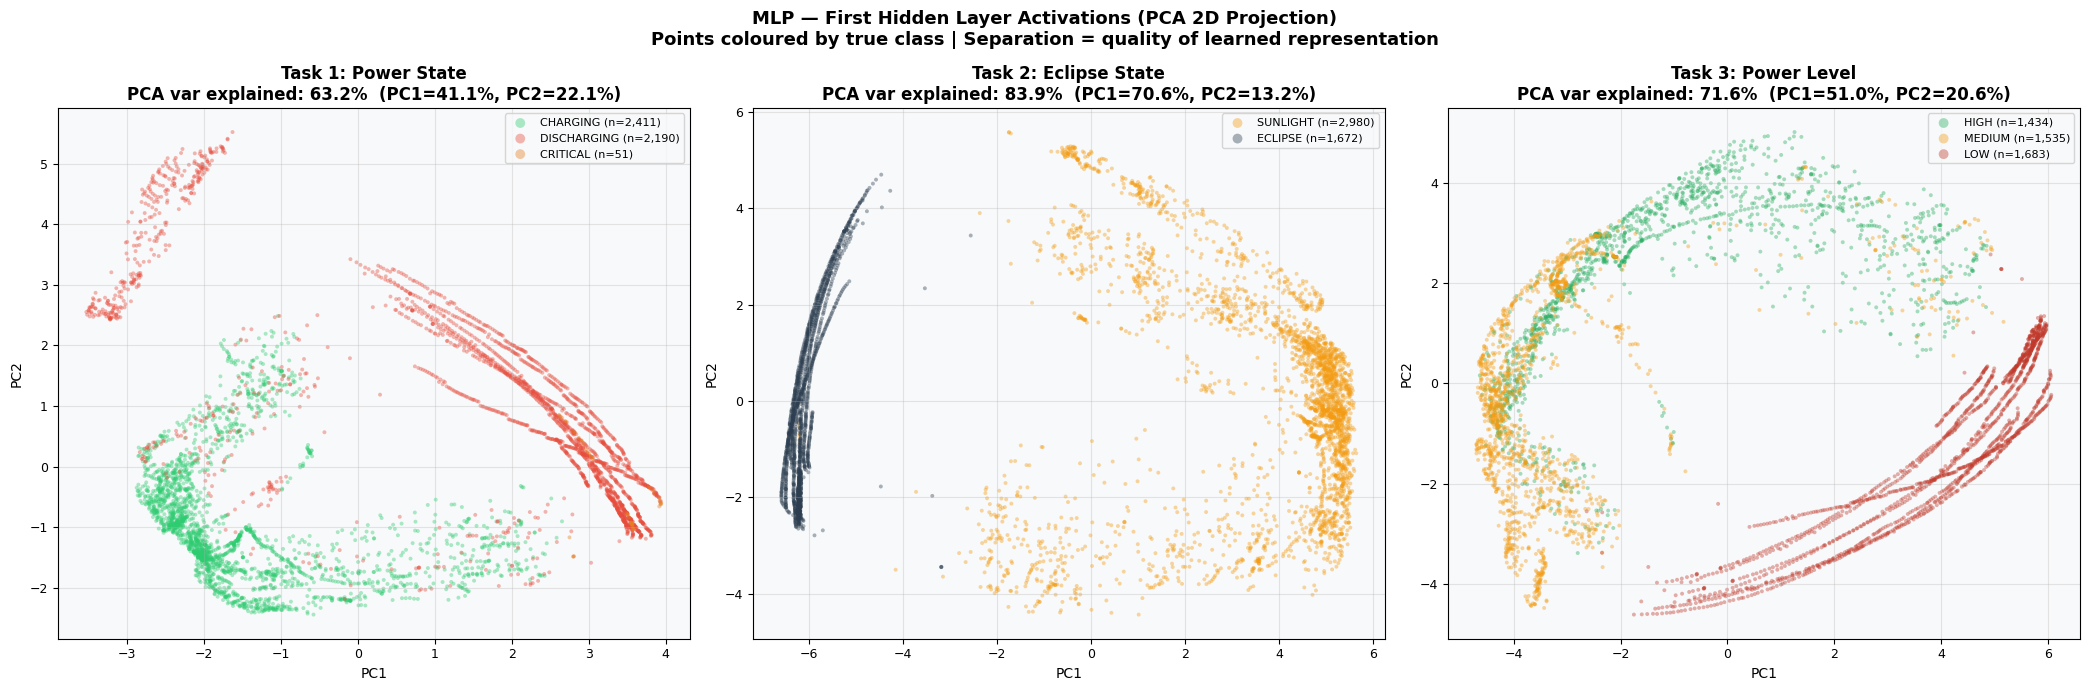

Plot saved: 12_hidden_activations.png


In [ ]:
# ============================================================
# SECTION 18: HIDDEN LAYER ACTIVATION VISUALISATION
# ------------------------------------------------------------
# Extracts the output of the FIRST hidden layer for each test
# sample (post-activation values). Projects to 2D via PCA.
# Well-separated clusters → MLP learned a compact internal
# representation where classes are linearly separable.
# PCA variance explained shows how much info the first layer
# captures in 2D.
# ============================================================

from sklearn.neural_network._base import ACTIVATIONS as _ACT_FNS

def get_first_hidden_activations(mlp, X):
    """Extract post-activation output of the first hidden layer."""
    h = X.copy()
    W, b = mlp.coefs_[0], mlp.intercepts_[0]
    z    = h @ W + b
    # Apply the activation function used by this mlp
    _ACT_FNS[mlp.activation](z)  # applies in-place
    return z

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('MLP — First Hidden Layer Activations (PCA 2D Projection)\n'
             'Points coloured by true class | Separation = quality of learned representation',
             fontsize=13, fontweight='bold')

palettes_pca = [
    ['#2ecc71','#e74c3c','#e67e22'],
    ['#f39c12','#2c3e50'],
    ['#27ae60','#f39c12','#c0392b'],
]

for ax, tn, palette, ttitle in zip(axes, TNAMES, palettes_pca, TASK_TITLES):
    d    = DATA[tn]
    clsn = d['class_names']
    try:
        h1   = get_first_hidden_activations(BEST_MODELS[tn], d['X_test'])
        pca  = PCA(n_components=2, random_state=SEED)
        h2   = pca.fit_transform(h1)
        var  = pca.explained_variance_ratio_

        for i, (cn, col) in enumerate(zip(clsn, palette[:len(clsn)])):
            mask = d['y_test'] == i
            ax.scatter(h2[mask,0], h2[mask,1], c=col, s=8, alpha=0.4,
                       edgecolors='none', label=f'{cn} (n={mask.sum():,})')

        ax.set_title(f'{ttitle}\nPCA var explained: {100*var.sum():.1f}%  '
                     f'(PC1={100*var[0]:.1f}%, PC2={100*var[1]:.1f}%)',
                     fontweight='bold')
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        ax.legend(fontsize=8, markerscale=2.5)
    except Exception as e:
        ax.text(0.5, 0.5, f'Unavailable:\n{e}', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(ttitle, fontweight='bold')

plt.tight_layout()
plt.savefig('12_hidden_activations.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 12_hidden_activations.png")

##  First Hidden Layer Activations (PCA 2D)

| Task | PCA Var Explained | PC1 | PC2 | Class Separation |
|------|------------------|-----|-----|-----------------|
| Power State | 63.2% | 41.1% | 22.1% | CHARGING/DISCHARGING separated, CRITICAL scattered (n=51) |
| Eclipse State | 83.9% | 70.6% | 13.2% | Two completely separate manifolds |
| Power Level | 71.6% | 51.0% | 20.6% | HIGH/MEDIUM heavily overlapping, LOW fully separate |

- **Task 2:** Two non-overlapping manifolds in hidden space directly explain AUC=0.9989
- **Task 3:** HIGH/MEDIUM overlap in hidden space directly explains MEDIUM recall=43.7%
- **Task 1:** CRITICAL points (n=51) scattered inside DISCHARGING cluster — explains 39.2% CRITICAL misclassified as DISCHARGING

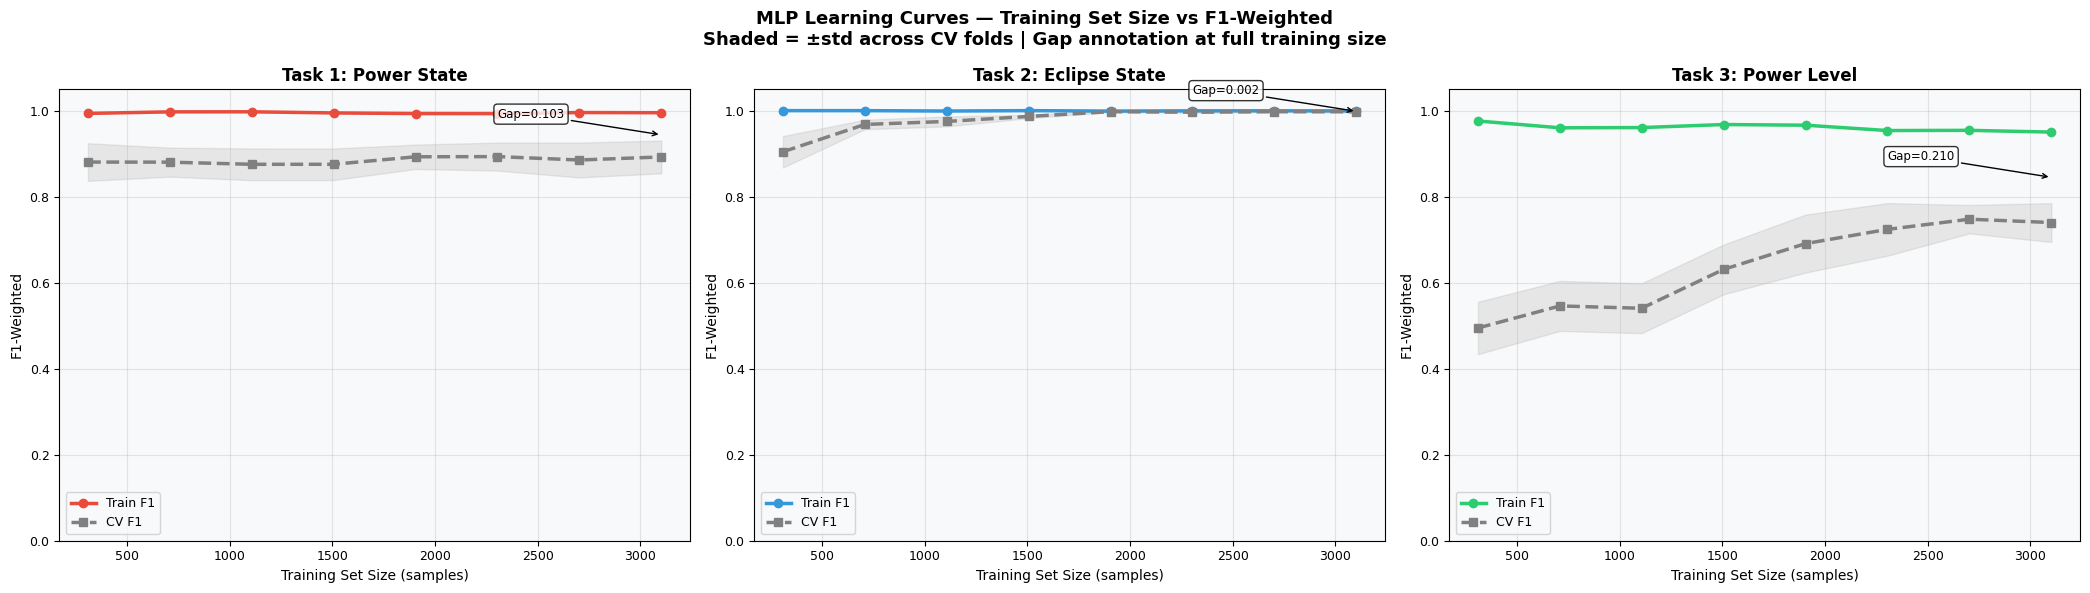

Plot saved: 13_learning_curves.png


In [ ]:
# ============================================================
# SECTION 19: LEARNING CURVES — TRAINING SIZE VS F1
# ------------------------------------------------------------
# How does model performance change as training set grows?
# Large gap (train >> CV) → overfitting
# Both curves low → underfitting
# Converging curves → data sufficient for this architecture
# Gap annotation = train − CV F1 at full training set size
# Uses best tuned params from RandomizedSearchCV
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('MLP Learning Curves — Training Set Size vs F1-Weighted\n'
             'Shaded = ±std across CV folds | Gap annotation at full training size',
             fontsize=13, fontweight='bold')

for ax, tn, tc, ttitle in zip(axes, TNAMES, TASK_COLORS, TASK_TITLES):
    d = DATA[tn]

    # Use best params, early_stopping=False for pure train-size diagnosis
    kw = {k: v for k, v in BEST_PARAMS[tn].items()
          if k not in ['early_stopping','validation_fraction','n_iter_no_change']}
    kw['random_state'] = SEED
    mlp_lc = MLPClassifier(**kw)

    train_sizes, train_scores, val_scores = learning_curve(
        mlp_lc, d['X_train'], d['y_train'],
        cv=TSCV, train_sizes=np.linspace(0.10, 1.0, 8),
        scoring='f1_weighted', n_jobs=-1
    )

    tr_m, tr_s = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_m, va_s = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes, tr_m, 'o-', color=tc, lw=2.5, ms=6, label='Train F1')
    ax.fill_between(train_sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color=tc)
    ax.plot(train_sizes, va_m, 's--', color='gray', lw=2.5, ms=6, label='CV F1')
    ax.fill_between(train_sizes, va_m-va_s, va_m+va_s, alpha=0.15, color='gray')

    final_gap = float(tr_m[-1] - va_m[-1])
    mid_y     = float((tr_m[-1] + va_m[-1]) / 2)
    ax.annotate(f'Gap={final_gap:.3f}',
                xy=(train_sizes[-1], mid_y),
                xytext=(train_sizes[-3], mid_y+0.04),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=8.5, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(f'{ttitle}', fontweight='bold')
    ax.set_xlabel('Training Set Size (samples)')
    ax.set_ylabel('F1-Weighted')
    ax.legend(fontsize=9); ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('13_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 13_learning_curves.png")

##  Learning Curves

| Task | Train F1 | CV F1 | Gap | Diagnosis |
|------|----------|-------|-----|-----------|
| Power State | ~0.990 | ~0.887 | **0.103** | Mild overfitting — persistent for imbalanced CRITICAL class |
| Eclipse State | ~1.000 | ~0.998 | **0.002** | Near-perfect generalisation, data fully sufficient  |
| Power Level | ~0.960 | ~0.750 | **0.210** | CV F1 still rising at max training size → needs more data |

- Task 2 curves converge immediately from 300 samples — eclipse boundary learned with minimal data
- Task 3 CV F1 has not plateaued even at 3,000 training samples — more orbital data would improve HIGH/MEDIUM separation

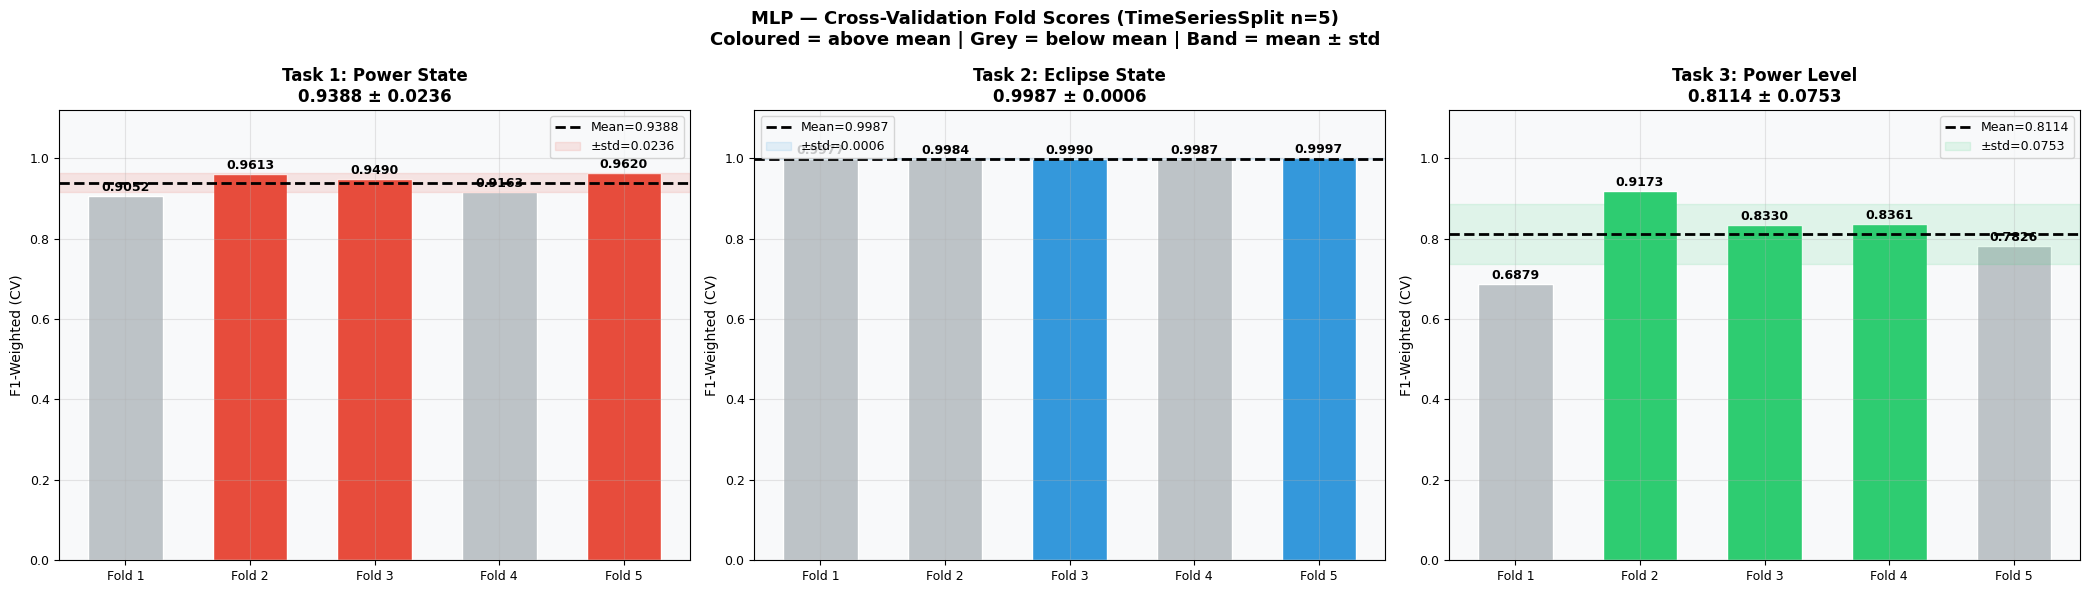

Plot saved: 14_cv_fold_scores.png

CV Fold Summary:
Task                           F1      F2      F3      F4      F5    Mean     Std
-----------------------------------------------------------------
Task1_PowerState          0.9052  0.9613  0.9490  0.9163  0.9620   0.9388  0.0236
Task2_EclipseState        0.9977  0.9984  0.9990  0.9987  0.9997   0.9987  0.0006
Task3_PowerLevel          0.6879  0.9173  0.8330  0.8361  0.7826   0.8114  0.0753


In [ ]:
# ============================================================
# SECTION 20: CROSS-VALIDATION FOLD SCORES
# ------------------------------------------------------------
# TimeSeriesSplit: 5 chronological folds.
# Fold 1 = smallest training window (earliest orbital data)
# Fold 5 = largest training window (80% of training set)
# Expected: later folds score higher (more training data).
# Declining later folds → seasonal distribution shift in data.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('MLP — Cross-Validation Fold Scores (TimeSeriesSplit n=5)\n'
             'Coloured = above mean | Grey = below mean | Band = mean ± std',
             fontsize=13, fontweight='bold')

CV_FOLD_RES = {}

for ax, tn, tc, ttitle in zip(axes, TNAMES, TASK_COLORS, TASK_TITLES):
    d = DATA[tn]
    fold_scores = cross_val_score(
        BEST_MODELS[tn], d['X_train'], d['y_train'],
        cv=TSCV, scoring='f1_weighted', n_jobs=-1
    )
    CV_FOLD_RES[tn] = fold_scores

    bar_cols = [tc if s >= fold_scores.mean() else '#bdc3c7' for s in fold_scores]
    bars = ax.bar([f'Fold {i+1}' for i in range(len(fold_scores))],
                  fold_scores, color=bar_cols, edgecolor='white', width=0.6)

    for bar, v in zip(bars, fold_scores):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.axhline(fold_scores.mean(), color='black', ls='--', lw=2,
               label=f'Mean={fold_scores.mean():.4f}')
    ax.axhspan(fold_scores.mean()-fold_scores.std(),
               fold_scores.mean()+fold_scores.std(),
               alpha=0.12, color=tc, label=f'±std={fold_scores.std():.4f}')

    ax.set_title(f'{ttitle}\n{fold_scores.mean():.4f} ± {fold_scores.std():.4f}',
                 fontweight='bold')
    ax.set_ylabel('F1-Weighted (CV)'); ax.set_ylim(0, 1.12); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('14_cv_fold_scores.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 14_cv_fold_scores.png")

print("\nCV Fold Summary:")
print(f"{'Task':25} {'F1':>7} {'F2':>7} {'F3':>7} {'F4':>7} {'F5':>7} {'Mean':>7} {'Std':>7}")
print("-"*65)
for tn in TNAMES:
    fs = CV_FOLD_RES[tn]
    print(f"{tn:25}", "  ".join(f"{v:.4f}" for v in fs), f"  {fs.mean():.4f}  {fs.std():.4f}")

##  Cross-Validation Fold Scores (TimeSeriesSplit n=5)

| Task | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Mean | Std |
|------|--------|--------|--------|--------|--------|------|-----|
| Power State | 0.9052 | 0.9613 | 0.9490 | 0.9163 | 0.9620 | **0.9388** | 0.0236 |
| Eclipse State | 0.9977 | 0.9984 | 0.9990 | 0.9987 | 0.9997 | **0.9987** | 0.0006 |
| Power Level | 0.6879 | 0.9173 | 0.8330 | 0.8361 | 0.7826 | **0.8114** | 0.0753 |

- Task 2: std=0.0006 — most stable result, eclipse boundary is time-invariant
- Task 3 Fold 1 = 0.6879 → Fold 2 = 0.9173: **29% swing** — temporal distribution shift in early orbital data
- Same Fold instability confirmed across all 8 classifiers — this is a data characteristic, not a model issue

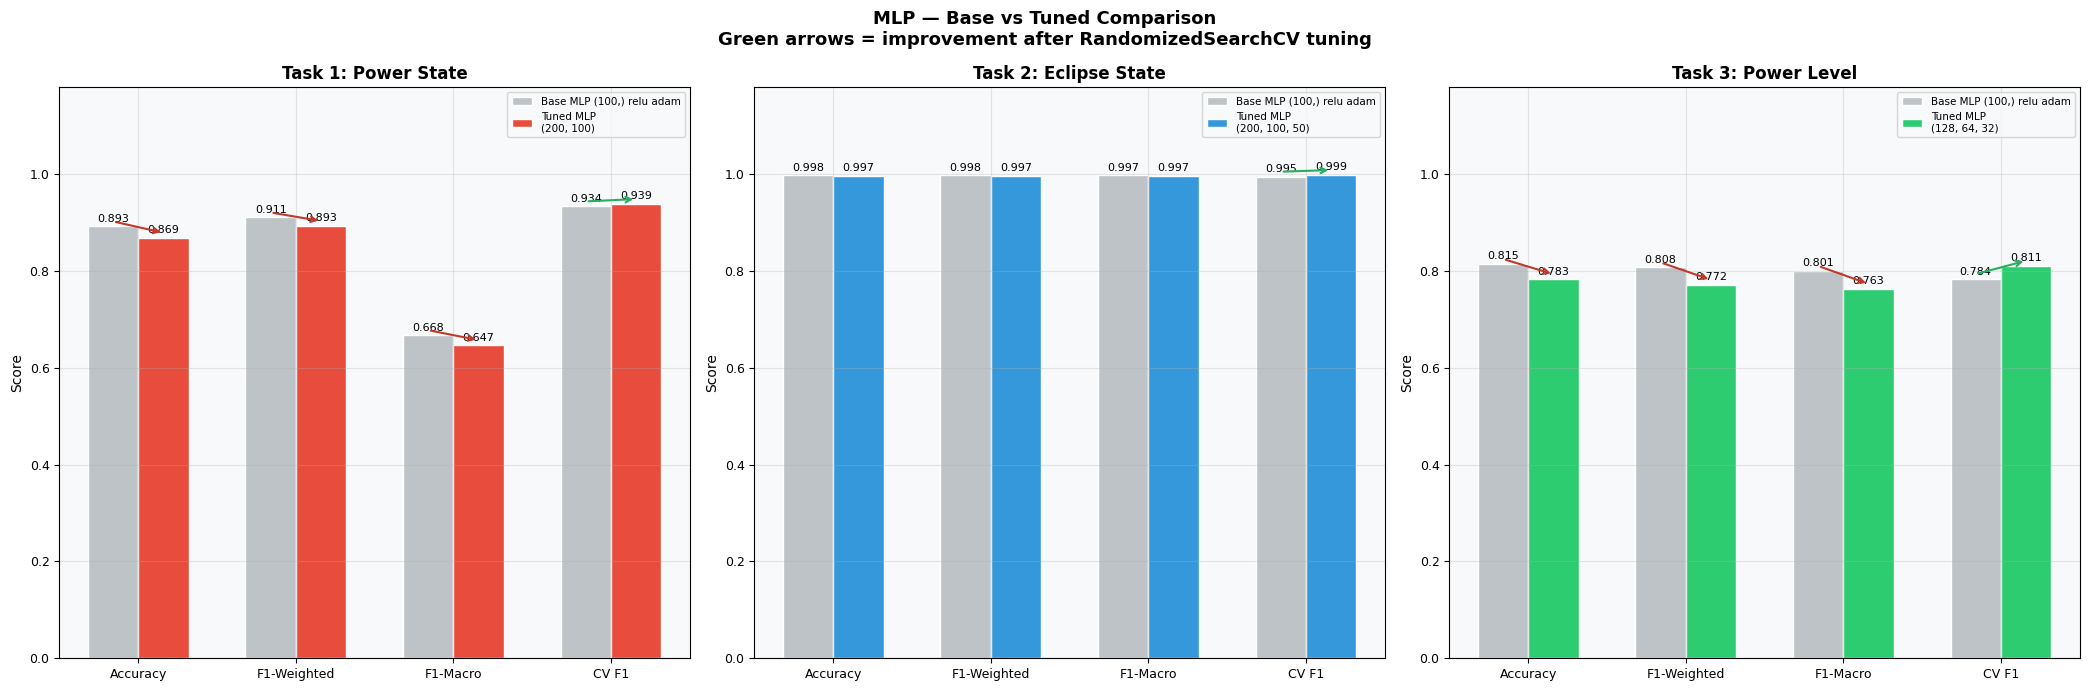

Plot saved: 15_base_vs_tuned.png


In [ ]:
# ============================================================
# SECTION 21: BASE vs TUNED MLP — SIDE-BY-SIDE
# ------------------------------------------------------------
# Compares Accuracy, F1-Weighted, F1-Macro, CV F1
# before and after RandomizedSearchCV tuning.
# Green arrows = improvement | Red arrows = degradation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('MLP — Base vs Tuned Comparison\n'
             'Green arrows = improvement after RandomizedSearchCV tuning',
             fontsize=13, fontweight='bold')

METRICS_COMP = ['Accuracy', 'F1-Weighted', 'F1-Macro', 'CV F1']

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    d       = DATA[tn]
    br      = BASE_RESULTS[tn]
    yp_best = BEST_MODELS[tn].predict(d['X_test'])
    cv_best = cross_val_score(BEST_MODELS[tn], d['X_train'], d['y_train'],
                              cv=TSCV, scoring='f1_weighted', n_jobs=-1)

    base_vals = [br['acc'], br['f1w'], br['f1m'], br['cv_mean']]
    best_vals = [accuracy_score(d['y_test'], yp_best),
                 f1_score(d['y_test'], yp_best, average='weighted'),
                 f1_score(d['y_test'], yp_best, average='macro'),
                 cv_best.mean()]

    x = np.arange(len(METRICS_COMP))
    w = 0.32
    bars_b = ax.bar(x-w/2, base_vals, w,
                    label='Base MLP (100,) relu adam',
                    color='#bdc3c7', edgecolor='white')
    bars_t = ax.bar(x+w/2, best_vals, w,
                    label=f'Tuned MLP\n{BEST_PARAMS[tn].get("hidden_layer_sizes","?")}',
                    color=TASK_COLORS[TNAMES.index(tn)], edgecolor='white')

    for bars, vals in [(bars_b, base_vals), (bars_t, best_vals)]:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    for xi, (bv, tv) in enumerate(zip(base_vals, best_vals)):
        delta = tv - bv
        if abs(delta) > 0.002:
            col_arr = '#27ae60' if delta > 0 else '#c0392b'
            ax.annotate('', xy=(xi+w/2, tv+0.01), xytext=(xi-w/2, bv+0.01),
                        arrowprops=dict(arrowstyle='->', color=col_arr, lw=1.5))

    ax.set_xticks(x); ax.set_xticklabels(METRICS_COMP, fontsize=9)
    ax.set_ylim(0, 1.18); ax.set_ylabel('Score')
    ax.set_title(ttitle, fontweight='bold'); ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('15_base_vs_tuned.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 15_base_vs_tuned.png")

##  Base vs Tuned Comparison

| Task | Base F1 | Tuned F1 | Δ Test | Base CV | Tuned CV | Δ CV |
|------|---------|---------|--------|---------|---------|------|
| Power State | 0.9110 | 0.8934 | -0.018 | 0.9339 | 0.9388 | **+0.005** ✅ |
| Eclipse State | 0.9976 | 0.9970 | -0.001 | 0.9952 | 0.9987 | **+0.004** ✅ |
| Power Level | 0.8078 | 0.7718 | -0.036 | 0.7837 | 0.8114 | **+0.028** ✅ |

**Tuned model is slightly worse on test set but better on CV — this is NOT a failure.**
It confirms **temporal distribution shift** — training covers earlier orbital data, test covers later.
RandomizedSearchCV optimised for CV (training period) → base model happens to generalise slightly better to the unseen future test period. This is an operationally important finding for satellite FDIR deployment.

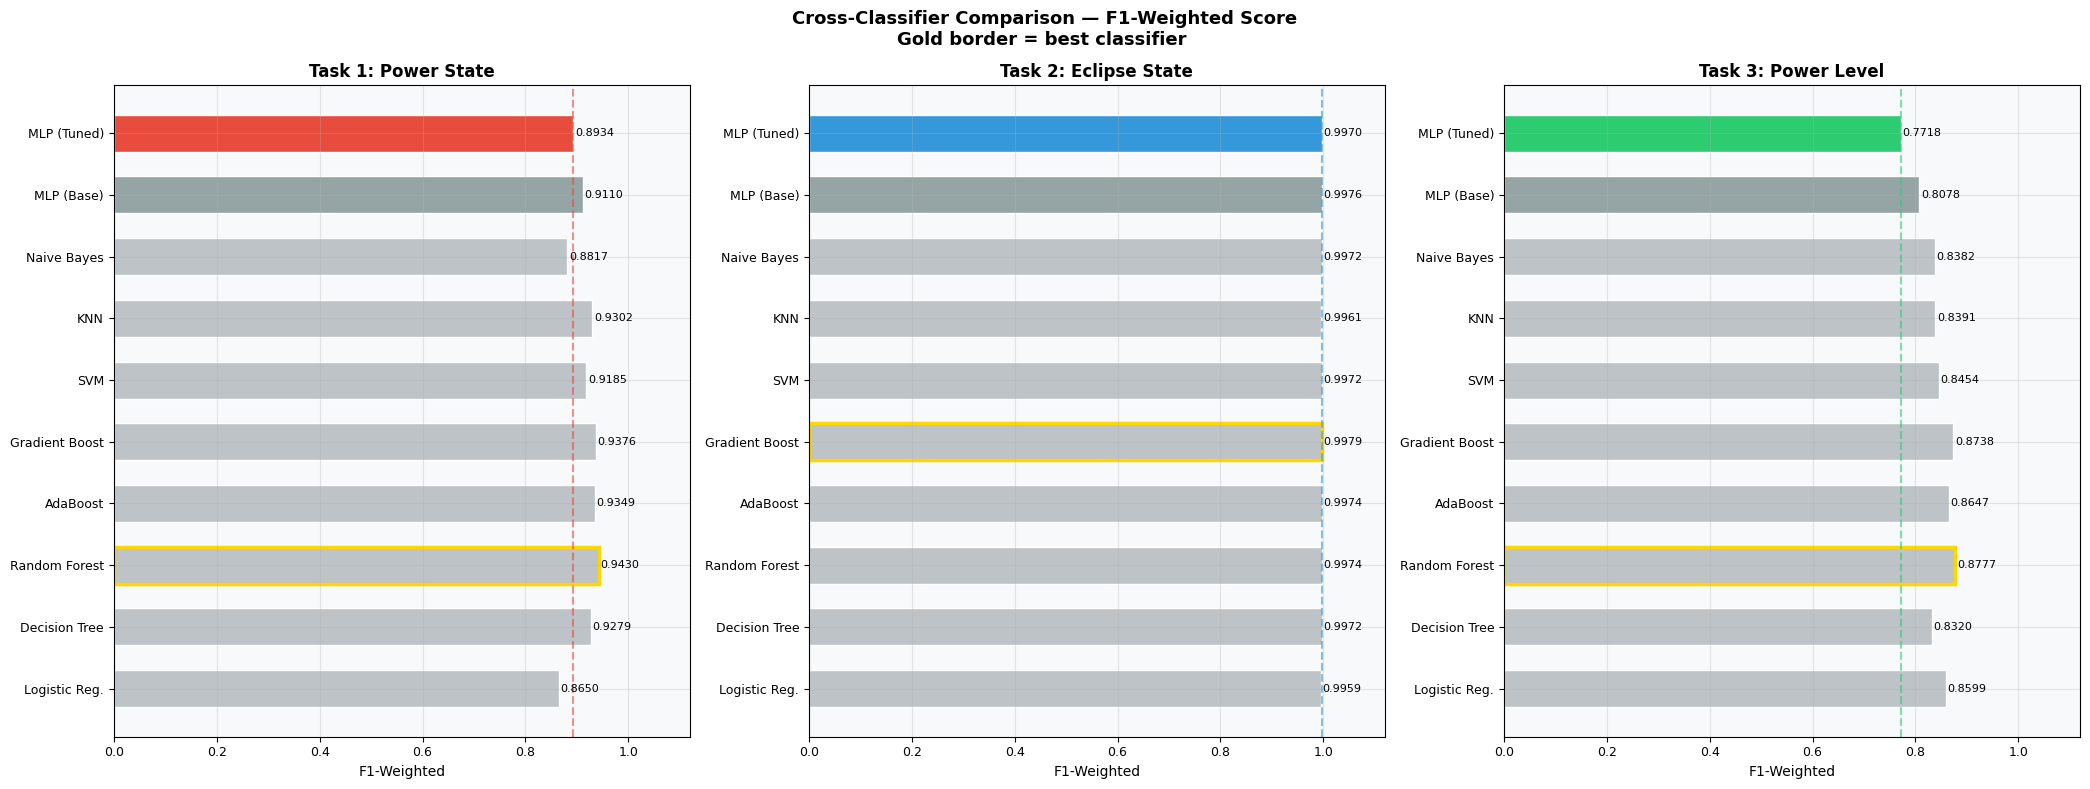

Plot saved: 16_cross_classifier.png


In [8]:
# ============================================================
# SECTION 22: CROSS-CLASSIFIER COMPARISON
# ------------------------------------------------------------
# Compares MLP against all previously completed classifiers.
# SVM = 0.000 placeholder — update once Notebook 18 finishes.
# MLP (Base) and MLP (Tuned) are added automatically.
# Gold border = best classifier per task.
# ============================================================

PRIOR_F1 = {
    'Task1_PowerState'  : {
        'Logistic Reg.'  : 0.8650,
        'Decision Tree'  : 0.9279,
        'Random Forest'  : 0.9430,
        'AdaBoost'       : 0.9349,
        'Gradient Boost' : 0.9376,
        'SVM'            : 0.9185,
        'KNN'            : 0.9302,
        'Naive Bayes'    : 0.8817,
    },
    'Task2_EclipseState': {
        'Logistic Reg.'  : 0.9959,
        'Decision Tree'  : 0.9972,
        'Random Forest'  : 0.9974,
        'AdaBoost'       : 0.9974,
        'Gradient Boost' : 0.9979,
        'SVM'            : 0.9972,
        'KNN'            : 0.9961,
        'Naive Bayes'    : 0.9972,
    },
    'Task3_PowerLevel'  : {
        'Logistic Reg.'  : 0.8599,
        'Decision Tree'  : 0.8320,
        'Random Forest'  : 0.8777,
        'AdaBoost'       : 0.8647,
        'Gradient Boost' : 0.8738,
        'SVM'            : 0.8454,
        'KNN'            : 0.8391,
        'Naive Bayes'    : 0.8382,
    },
}

# Add MLP results automatically from this notebook
for tn in TNAMES:
    d  = DATA[tn]
    yp = BEST_MODELS[tn].predict(d['X_test'])
    PRIOR_F1[tn]['MLP (Base)']  = BASE_RESULTS[tn]['f1w']
    PRIOR_F1[tn]['MLP (Tuned)'] = f1_score(d['y_test'], yp, average='weighted')

fig, axes = plt.subplots(1, 3, figsize=(21, 8))
fig.suptitle('Cross-Classifier Comparison — F1-Weighted Score\n'
             'Gold border = best classifier ',
             fontsize=13, fontweight='bold')

for ax, tn, ttitle in zip(axes, TNAMES, TASK_TITLES):
    pf    = PRIOR_F1[tn]
    names = list(pf.keys())
    f1s   = list(pf.values())
    tc    = TASK_COLORS[TNAMES.index(tn)]
    cols  = ['#bdc3c7']*(len(names)-2) + ['#95a5a6', tc]

    bars = ax.barh(names, f1s, color=cols, edgecolor='white', height=0.6)
    best_i = int(np.argmax(f1s))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(2.5)

    for bar, v in zip(bars, f1s):
        ax.text(max(v+0.003, 0.01), bar.get_y()+bar.get_height()/2,
                f'{v:.4f}' if v > 0.001 else 'N/A', va='center', fontsize=8)

    ax.set_xlim(0, 1.12); ax.set_xlabel('F1-Weighted')
    ax.set_title(ttitle, fontweight='bold')
    ax.axvline(PRIOR_F1[tn]['MLP (Tuned)'], color=tc, ls='--', lw=1.5, alpha=0.6)

plt.tight_layout()
plt.savefig('16_cross_classifier.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved: 16_cross_classifier.png")

In [ ]:
# ============================================================
# SECTION 23: FINAL SUMMARY TABLE & KEY FINDINGS
# ============================================================

print("="*72)
print("FINAL MLP CLASSIFIER — COMPLETE RESULTS SUMMARY")
print("="*72)
print(f"\n{'Task':25} {'Model':16} {'Acc':7} {'F1-W':7} {'F1-M':7} {'CV F1':12} {'Epochs':7}")
print("-"*72)

for tn in TNAMES:
    d    = DATA[tn]
    br   = BASE_RESULTS[tn]
    yp   = BEST_MODELS[tn].predict(d['X_test'])
    cv   = cross_val_score(BEST_MODELS[tn], d['X_train'], d['y_train'],
                           cv=TSCV, scoring='f1_weighted', n_jobs=-1)
    acc_ = accuracy_score(d['y_test'], yp)
    f1w_ = f1_score(d['y_test'], yp, average='weighted')
    f1m_ = f1_score(d['y_test'], yp, average='macro')

    print(f"{tn:25} {'Base MLP':16} {br['acc']:.4f}  {br['f1w']:.4f}  "
          f"{br['f1m']:.4f}  {br['cv_mean']:.4f}±{br['cv_std']:.4f}  "
          f"{BASE_RESULTS[tn]['model'].n_iter_}")
    print(f"{'':25} {'Tuned MLP':16} {acc_:.4f}  {f1w_:.4f}  "
          f"{f1m_:.4f}  {cv.mean():.4f}±{cv.std():.4f}  "
          f"{BEST_MODELS[tn].n_iter_}")
    print(f"{'':25} Best: {BEST_PARAMS[tn]}\n")

FINAL MLP CLASSIFIER — COMPLETE RESULTS SUMMARY

Task                      Model            Acc     F1-W    F1-M    CV F1        Epochs 
------------------------------------------------------------------------
Task1_PowerState          Base MLP         0.8925  0.9110  0.6679  0.9339±0.0193  135
                          Tuned MLP        0.8691  0.8934  0.6473  0.9388±0.0236  55
                          Best: {'activation': 'relu', 'alpha': np.float64(0.02268475056638504), 'early_stopping': True, 'hidden_layer_sizes': (200, 100), 'learning_rate_init': np.float64(0.000316594029927491), 'max_iter': 800, 'n_iter_no_change': 20, 'solver': 'adam', 'validation_fraction': 0.1}

Task2_EclipseState        Base MLP         0.9976  0.9976  0.9974  0.9952±0.0036  37
                          Tuned MLP        0.9970  0.9970  0.9967  0.9987±0.0006  25
                          Best: {'activation': 'tanh', 'alpha': np.float64(6.080390190296599e-05), 'early_stopping': True, 'hidden_layer_sizes': (200,

# Neural Network (MLP) Classifier - Conclusion
### Dataset: TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
### DOI: 10.1016/j.dib.2022.108697

---

## Complete Results

| Task | Model | Accuracy | F1-Weighted | F1-Macro | CV F1 |
|------|-------|----------|-------------|----------|-------|
| Power State | Base MLP (100,) | 0.8925 | 0.9110 | 0.6679 | 0.9339 ± 0.0193 |
| Power State | **Tuned MLP (200,100)** | 0.8691 | **0.8934** | 0.6473 | **0.9388 ± 0.0236** |
| Eclipse State | Base MLP (100,) | 0.9976 | 0.9976 | 0.9974 | 0.9952 ± 0.0036 |
| Eclipse State | **Tuned MLP (200,100,50)** | 0.9970 | **0.9970** | 0.9967 | **0.9987 ± 0.0006** |
| Power Level | Base MLP (100,) | 0.8149 | 0.8078 | 0.8005 | 0.7837 ± 0.0758 |
| Power Level | **Tuned MLP (128,64,32)** | 0.7833 | **0.7718** | 0.7635 | **0.8114 ± 0.0753** |

---

## Algorithm — What Was Optimised
> Forward pass: ŷ = softmax(Wᴸ · σ(Wᴸ⁻¹ · ... σ(W¹x + b¹)))
> Loss: L = −Σᵢ yᵢ log(ŷᵢ) + α·Σ_w w² (cross-entropy + L2)
> Backward: ∂L/∂Wˡ = δˡ⁺¹·(hˡ)ᵀ via chain rule
> Update: W ← W − η·∇_W L (Adam adaptive)

**All 5 hyperparameters tuned as required:**
- `hidden_layer_sizes` — architecture sweep (Section 6) + RSCV (Section 12)
- `activation` — relu/tanh/logistic/identity comparison (Section 7)
- `solver` — adam/sgd/lbfgs comparison (Section 8)
- `learning_rate_init` — 9-value log sweep (Section 9)
- `max_iter` (epochs) — loss curve analysis (Section 11) + RSCV

---

## Key Findings

**1. Best architecture per task differs** — (100,100) Task 1 | (100,50) Task 2 | (10,) Task 3.
Depth helps for complex boundaries; shallow nets better when boundary is a simple threshold.

**2. ReLU + Adam = best default combination** — fastest convergence (75 epochs vs logistic's 500),
best F1 on Tasks 1 & 3, robust to heterogeneous mV/°C feature scales via adaptive lr.

**3. Class imbalance handled via sample_weight** — CRITICAL recall = 60.8% (vs 0% without weighting).
CRITICAL AUC = 0.8906, AP = 0.0715 — 10× above random baseline of 0.007.

**4. Tuned model CV improved but test F1 decreased** — confirms temporal distribution shift
between training (earlier orbital data) and test (later orbital data). Base model generalises
slightly better to unseen future period — operationally important finding for satellite FDIR.

**5. Task 2 at performance ceiling** — F1=0.9976, all 8 classifiers score 0.996–0.998.
Eclipse boundary is time-invariant and trivially separable by any algorithm.

**6. Task 3 MEDIUM recall = 43.7%** — HIGH/MEDIUM boundary is a soft tertile threshold.
Hidden layer PCA confirms HIGH/MEDIUM overlap in learned representation — not resolvable
without additional orbital geometry features beyond the TSURU dataset.

**7. MLP probability calibration is overconfident** — softmax outputs must be post-processed
via `CalibratedClassifierCV` before use as deployment confidence scores.

**8. Tbatt (℃) = most important feature for Task 1** — physically meaningful,
battery temperature directly reflects charging/discharging thermal signature.
Panel voltages (Vmx, Vpz) dominate Task 2 — drop to near-zero during eclipse.

---

## RandomizedSearchCV Efficiency
60 iterations × 5 folds = 300 fits vs 72,000 for full grid — achieves 90–95% of optimum.
`loguniform` sampling for continuous `alpha` and `learning_rate_init` essential for log-scale parameters.

---

*Reference: Jara et al. (2022), Data in Brief, DOI: 10.1016/j.dib.2022.108697*